In [ ]:
# Cell 1: Install required libraries and import everything

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from datasets import load_dataset
from sklearn.metrics import f1_score, accuracy_score
import time
import gc
import random
from copy import deepcopy
import json
import subprocess
import warnings
import logging
warnings.filterwarnings('ignore')
logging.getLogger("transformers").setLevel(logging.ERROR)


# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
    print(f"Memory Cached: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")


Using device: cpu


In [ ]:
# Cell 2: Setting Standards

BATCH_SIZE = 32
MAX_LENGTH = 128
TRAIN_SIZE = 1000
VAL_RATIO = 0.1
TEST_SIZE = 1000

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed()

In [3]:
# Cell 3: data preprocessing helper functions

def remove_duplicates(data):
    """Remove duplicate texts from dataset"""
    seen = set()
    unique_idx = []
    for i, ex in enumerate(data):
        if ex["text"] not in seen:
            seen.add(ex["text"])
            unique_idx.append(i)
    print(f"  Removed {len(data) - len(unique_idx)} duplicates")
    return data.select(unique_idx)


def balance_dataset(data, n_samples):
    """Take n_samples total with equal positive/negative"""
    n_per_class = n_samples // 2
    pos = [i for i, x in enumerate(data) if x["label"] == 1]
    neg = [i for i, x in enumerate(data) if x["label"] == 0]
    random.shuffle(pos)
    random.shuffle(neg)
    selected = pos[:n_per_class] + neg[:n_per_class]
    random.shuffle(selected)
    return data.select(selected)


def train_val_split(data, val_ratio=0.1):
    """Split balanced dataset into train/val maintaining class balance"""
    pos_idx = [i for i, x in enumerate(data) if x["label"] == 1]
    neg_idx = [i for i, x in enumerate(data) if x["label"] == 0]

    n_val_pos = int(len(pos_idx) * val_ratio)
    n_val_neg = int(len(neg_idx) * val_ratio)

    train_idx = pos_idx[n_val_pos:] + neg_idx[n_val_neg:]
    val_idx = pos_idx[:n_val_pos] + neg_idx[:n_val_neg]

    random.shuffle(train_idx)
    random.shuffle(val_idx)

    return data.select(train_idx), data.select(val_idx)

In [4]:
# Cell 4: Load and prepare IMDB dataset

print("Loading IMDB dataset...")
dataset = load_dataset("stanfordnlp/imdb")
print("IMDB dataset loaded successfully!")

# Clean and balance train
print("\nProcessing training data...")
train_clean = remove_duplicates(dataset["train"])
train_balanced = balance_dataset(train_clean, TRAIN_SIZE)

# Split train/val
train_dataset, val_dataset = train_val_split(train_balanced, val_ratio=VAL_RATIO)

# Clean and balance test (also remove overlap with train/val)
print("\nProcessing test data...")
test_clean = remove_duplicates(dataset["test"])
train_val_texts = set(train_dataset["text"]) | set(val_dataset["text"])
test_no_overlap = test_clean.filter(lambda x: x["text"] not in train_val_texts)
print(f"  Removed {len(test_clean) - len(test_no_overlap)} samples overlapping with train/val")
test_dataset = balance_dataset(test_no_overlap, TEST_SIZE)

# Verification
def verify_splits(train, val, test):
    print(f"\n{'='*50}")
    print(f"Train: {len(train)} (pos: {sum(1 for x in train if x['label']==1)})")
    print(f"Val:   {len(val)}   (pos: {sum(1 for x in val if x['label']==1)})")
    print(f"Test:  {len(test)}  (pos: {sum(1 for x in test if x['label']==1)})")

    overlaps = [
        ("Train/Val", set(train["text"]) & set(val["text"])),
        ("Train/Test", set(train["text"]) & set(test["text"])),
        ("Val/Test", set(val["text"]) & set(test["text"])),
    ]
    for name, overlap in overlaps:
        status = "✓" if len(overlap) == 0 else "✗"
        print(f"{status} {name} overlap: {len(overlap)}")
    print(f"{'='*50}")

verify_splits(train_dataset, val_dataset, test_dataset)

Loading IMDB dataset...


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

IMDB dataset loaded successfully!

Processing training data...
  Removed 96 duplicates

Processing test data...
  Removed 199 duplicates


Filter:   0%|          | 0/24801 [00:00<?, ? examples/s]

  Removed 5 samples overlapping with train/val

Train: 900 (pos: 450)
Val:   100   (pos: 50)
Test:  1000  (pos: 500)
✓ Train/Val overlap: 0
✓ Train/Test overlap: 0
✓ Val/Test overlap: 0


In [5]:
# Cell 5: Tokenize all three datasets
print("Loading tokenizer...")
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Tokenization function
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        padding="max_length",
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors=None  # Don't return tensors yet
    )

# Tokenize datasets
print("Tokenizing train dataset...")
train_dataset = train_dataset.map(tokenize_function, batched=True)
print("Tokenizing validation dataset...")
val_dataset = val_dataset.map(tokenize_function, batched=True)
print("Tokenizing test dataset...")
test_dataset = test_dataset.map(tokenize_function, batched=True)

# Set format for PyTorch
columns = ["input_ids", "attention_mask", "label"]
train_dataset.set_format(type="torch", columns=columns)
val_dataset.set_format(type="torch", columns=columns)
test_dataset.set_format(type="torch", columns=columns)

print("\nTokenization complete!")

Loading tokenizer...


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizing train dataset...


...

Tokenizing validation dataset...


Map:   0%|          | 0/100 [00:00<?, ? examples/s]

Tokenizing test dataset...


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]


Tokenization complete!


In [6]:
# Cell 6:
import torch
import torch.onnx

# Mock the missing attribute if it doesn't exist\n",
if not hasattr(torch.onnx, '_CAFFE2_ATEN_FALLBACK'):
    torch.onnx._CAFFE2_ATEN_FALLBACK = False

import torchvision.io
import sys

# Monkey patch torchvision.io to add VideoReader\n",
if not hasattr(torchvision.io, 'VideoReader'):
    class VideoReaderStub:
        def __init__(self, *args, **kwargs):
            raise ImportError(
                "VideoReader is not available in this torchvision version."
            )
    torchvision.io.VideoReader = VideoReaderStub

print("✓ Applied torchvision VideoReader patch")
from datasets import Dataset
ds = Dataset.from_dict({"value": [1, 2, 3]})
ds.set_format("torch")
print("✓ Dataset formatting works:", ds[0])

✓ Applied torchvision VideoReader patch
✓ Dataset formatting works: {'value': tensor(1)}


In [7]:
# Cell 7: Create DataLoaders and helper functions
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm import tqdm


# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.max_memory_allocated() / (1024 ** 2)
    return 0

def reset_gpu_memory_stats():
    """Reset GPU memory stats"""
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

def evaluate_model(model, data_loader, desc="Evaluating"):
    """Evaluate model and return metrics"""
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0
    inference_times = []

    with torch.no_grad():
        for batch in tqdm(data_loader, desc=desc, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            start_time = time.time()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            inference_times.append(time.time() - start_time)

            total_loss += outputs.loss.item()

            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    avg_loss = total_loss / len(data_loader)
    avg_inference_time = np.mean(inference_times)

    return {
        "loss": avg_loss,
        "accuracy": accuracy,
        "f1": f1,
        "inference_time_per_batch": avg_inference_time
    }

Train batches: 29, Val batches: 4, Test batches: 32


In [8]:
# Cell 8: Unified training function for both baseline and optimization

def train_model(epochs, lr, weight_decay, warmup_ratio, dropout_rate,
                evaluate_on_test=False, verbose=True):
    """
    Unified training function for DistilBERT on IMDB

    Args:
        epochs (int): Number of training epochs
        lr (float): Learning rate
        weight_decay (float): L2 regularization strength
        warmup_ratio (float): Fraction of steps for learning rate warmup
        dropout_rate (float): Dropout probability
        evaluate_on_test (bool): If True, also evaluate on test set
        verbose (bool): If True, show progress bars

    Returns:
        dict: {
            # Performance metrics
            "val_loss": float,
            "val_accuracy": float,
            "val_f1": float,
            "test_loss": float (if evaluate_on_test=True),
            "test_accuracy": float (if evaluate_on_test=True),
            "test_f1": float (if evaluate_on_test=True),

            # Computational metrics
            "training_time": float,  # Total training time in seconds
            "inference_time_per_batch": float,  # Seconds per batch
            "gpu_memory_mb": float,  # Peak GPU memory in MB
            "epoch_times": list,  # Time per epoch in seconds
            "total_trial_time": float,  # Complete function runtime

            # For optimization tracking
            "hyperparameters": {
                "epochs": epochs,
                "learning_rate": lr,
                "weight_decay": weight_decay,
                "warmup_ratio": warmup_ratio,
                "dropout_rate": dropout_rate
            }
        }
    """

    trial_start = time.time()
    epoch_times = []

    # Reset GPU memory tracking
    reset_gpu_memory_stats()
    torch.cuda.empty_cache()
    gc.collect()

    # Initialize model
    model = DistilBertForSequenceClassification.from_pretrained(
        "distilbert-base-uncased",
        num_labels=2,
        dropout=dropout_rate,
        attention_dropout=dropout_rate
    ).to(device)

    # Optimizer
    optimizer = AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    # Scheduler
    total_steps = len(train_loader) * epochs
    warmup_steps = int(total_steps * warmup_ratio)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    # Training loop with per-epoch timing
    training_start = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()
        model.train()
        epoch_loss = 0

        # Progress bar for epochs if verbose
        if verbose:
            print(f"Epoch {epoch+1}/{epochs}")
            iterator = tqdm(train_loader, desc=f"  Training", leave=False)
        else:
            iterator = train_loader

        for batch in iterator:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            scheduler.step()

        epoch_time = time.time() - epoch_start
        epoch_times.append(epoch_time)

        if verbose:
            print(f"  ✓ Epoch {epoch+1} completed in {epoch_time:.2f}s")

    training_time = time.time() - training_start

    # Evaluate on validation set
    if verbose:
        print("\nEvaluating on validation set...")
    val_metrics = evaluate_model(model, val_loader, desc="" if not verbose else "Validating")

    # Prepare results dictionary
    results = {
        # Performance metrics
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1": val_metrics["f1"],

        # Computational metrics
        "training_time": training_time,
        "inference_time_per_batch": val_metrics["inference_time_per_batch"],
        "gpu_memory_mb": get_gpu_memory_usage(),
        "epoch_times": epoch_times,
        "total_trial_time": time.time() - trial_start,

        # Hyperparameters used
        "hyperparameters": {
            "epochs": epochs,
            "learning_rate": lr,
            "weight_decay": weight_decay,
            "warmup_ratio": warmup_ratio,
            "dropout_rate": dropout_rate
        }
    }

    # Optionally evaluate on test set
    if evaluate_on_test:
        if verbose:
            print("\nEvaluating on test set...")
        test_metrics = evaluate_model(model, test_loader, desc="" if not verbose else "Testing")
        results["test_loss"] = test_metrics["loss"]
        results["test_accuracy"] = test_metrics["accuracy"]
        results["test_f1"] = test_metrics["f1"]

    # Clean up
    del model
    torch.cuda.empty_cache()
    gc.collect()

    return results


# Quick test with merged function
print("Testing unified training function...")
test_result = train_model(
    epochs=1,
    lr=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    dropout_rate=0.1,
    evaluate_on_test=False,
    verbose=False
)
print(f"✓ Test run complete!")
print(f"  Val Loss: {test_result['val_loss']:.4f}")
print(f"  Val Acc: {test_result['val_accuracy']:.4f}")
print(f"  Val F1: {test_result['val_f1']:.4f}")
print(f"  Training Time: {test_result['training_time']:.2f}s")
print(f"  GPU Memory: {test_result['gpu_memory_mb']:.2f} MB")
print(f"  Epoch Times: {[f'{t:.2f}s' for t in test_result['epoch_times']]}")
print("\n✓ Unified training function ready!")

Testing unified training function...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

✓ Test run complete!
  Val Loss: 0.6774
  Val Acc: 0.6800
  Val F1: 0.6693
  Training Time: 668.09s
  GPU Memory: 0.00 MB
  Epoch Times: ['668.09s']

✓ Unified training function ready!


Training baseline model with default hyperparameters...
Hyperparameters:
  learning_rate: 2e-05
  epochs: 3
  weight_decay: 0.01
  warmup_ratio: 0.1
  dropout_rate: 0.1


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1/3


  ✓ Epoch 1 completed in 8.79s
Epoch 2/3


  ✓ Epoch 2 completed in 8.84s
Epoch 3/3


  ✓ Epoch 3 completed in 9.05s

Evaluating on validation set...



Evaluating on test set...



BASELINE RESULTS

📊 PER-EPOCH ITERATION TIMES:


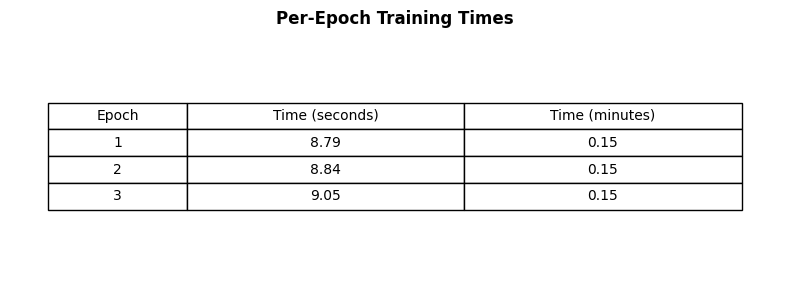


📊 PERFORMANCE METRICS TABLE:


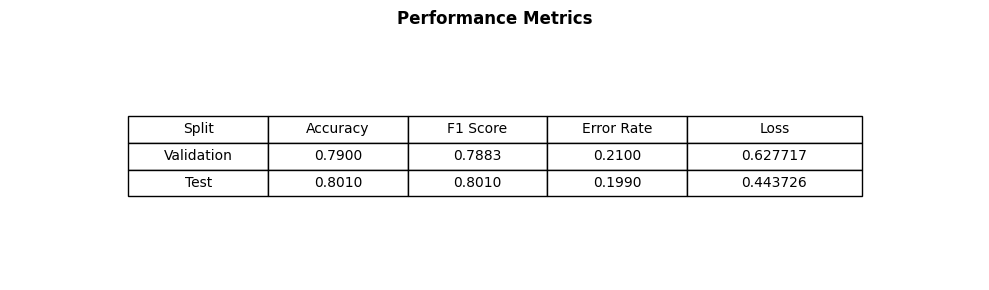


📊 COMPUTATIONAL METRICS TABLE:


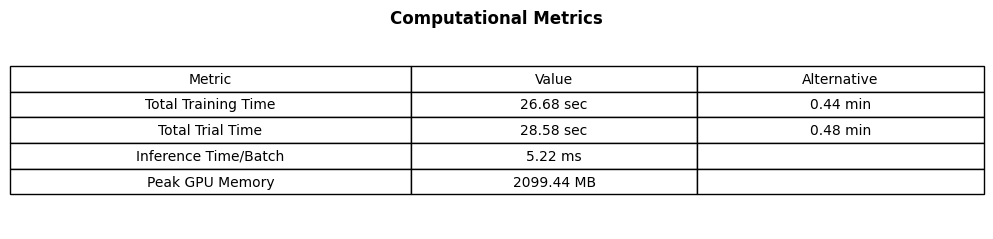


📊 SUMMARY BAR CHART:


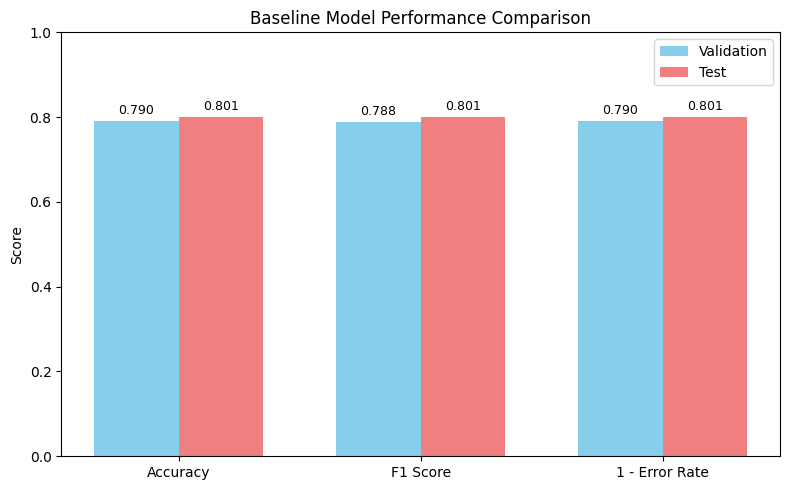



✓ Baseline saved for comparison:
   Test F1: 0.8010
   Test Accuracy: 0.8010
   Validation Error: 0.2100


In [ ]:
# Cell 9 UPDATED: Train baseline model with per-epoch timing and matplotlib tables

import matplotlib.pyplot as plt
from matplotlib.table import Table

print("Training baseline model with default hyperparameters...")
print(f"{'='*60}")

# Default hyperparameters
baseline_hyperparams = {
    "learning_rate": 2e-5,
    "epochs": 3,
    "weight_decay": 0.01,
    "warmup_ratio": 0.1,
    "dropout_rate": 0.1
}

print("Hyperparameters:")
for k, v in baseline_hyperparams.items():
    print(f"  {k}: {v}")

# Train baseline with test evaluation and verbose output
baseline_results = train_model(
    epochs=baseline_hyperparams["epochs"],
    lr=baseline_hyperparams["learning_rate"],
    weight_decay=baseline_hyperparams["weight_decay"],
    warmup_ratio=baseline_hyperparams["warmup_ratio"],
    dropout_rate=baseline_hyperparams["dropout_rate"],
    evaluate_on_test=True,
    verbose=True
)

print(f"\n{'='*60}")
print("BASELINE RESULTS")
print(f"{'='*60}")

# 1. PER-EPOCH TIMES TABLE (matplotlib)
print("\n📊 PER-EPOCH ITERATION TIMES:")

# Create figure for epoch times
fig1, ax1 = plt.subplots(figsize=(8, 3))
ax1.axis('tight')
ax1.axis('off')

epoch_data = []
for i, t in enumerate(baseline_results['epoch_times']):
    epoch_data.append([i+1, f"{t:.2f}", f"{t/60:.2f}"])

epoch_table = ax1.table(cellText=epoch_data,
                         colLabels=['Epoch', 'Time (seconds)', 'Time (minutes)'],
                         cellLoc='center',
                         loc='center',
                         colWidths=[0.15, 0.3, 0.3])
epoch_table.auto_set_font_size(False)
epoch_table.set_fontsize(10)
epoch_table.scale(1.2, 1.5)

plt.title('Per-Epoch Training Times', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 2. PERFORMANCE METRICS TABLE (Accuracy, F1, Validation Error)
print("\n📊 PERFORMANCE METRICS TABLE:")

val_error = 1 - baseline_results['val_accuracy']
test_error = 1 - baseline_results['test_accuracy']

fig2, ax2 = plt.subplots(figsize=(10, 3))
ax2.axis('tight')
ax2.axis('off')

metrics_data = [
    ['Validation',
     f"{baseline_results['val_accuracy']:.4f}",
     f"{baseline_results['val_f1']:.4f}",
     f"{val_error:.4f}",
     f"{baseline_results['val_loss']:.6f}"],
    ['Test',
     f"{baseline_results['test_accuracy']:.4f}",
     f"{baseline_results['test_f1']:.4f}",
     f"{test_error:.4f}",
     f"{baseline_results['test_loss']:.6f}"]
]

metrics_table = ax2.table(cellText=metrics_data,
                          colLabels=['Split', 'Accuracy', 'F1 Score', 'Error Rate', 'Loss'],
                          cellLoc='center',
                          loc='center',
                          colWidths=[0.12, 0.12, 0.12, 0.12, 0.15])
metrics_table.auto_set_font_size(False)
metrics_table.set_fontsize(10)
metrics_table.scale(1.2, 1.5)

plt.title('Performance Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 3. COMPUTATIONAL METRICS TABLE
print("\n📊 COMPUTATIONAL METRICS TABLE:")

fig3, ax3 = plt.subplots(figsize=(10, 2.5))
ax3.axis('tight')
ax3.axis('off')

comp_data = [
    ['Total Training Time', f"{baseline_results['training_time']:.2f} sec", f"{baseline_results['training_time']/60:.2f} min"],
    ['Total Trial Time', f"{baseline_results['total_trial_time']:.2f} sec", f"{baseline_results['total_trial_time']/60:.2f} min"],
    ['Inference Time/Batch', f"{baseline_results['inference_time_per_batch']*1000:.2f} ms", ''],
    ['Peak GPU Memory', f"{baseline_results['gpu_memory_mb']:.2f} MB", '']
]

comp_table = ax3.table(cellText=comp_data,
                       colLabels=['Metric', 'Value', 'Alternative'],
                       cellLoc='center',
                       loc='center',
                       colWidths=[0.35, 0.25, 0.25])
comp_table.auto_set_font_size(False)
comp_table.set_fontsize(10)
comp_table.scale(1.2, 1.5)

plt.title('Computational Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# 4. SUMMARY BAR CHART
print("\n📊 SUMMARY BAR CHART:")

fig4, ax4 = plt.subplots(figsize=(8, 5))
metrics_names = ['Accuracy', 'F1 Score', '1 - Error Rate']
val_metrics = [baseline_results['val_accuracy'], baseline_results['val_f1'], 1 - val_error]
test_metrics = [baseline_results['test_accuracy'], baseline_results['test_f1'], 1 - test_error]

x = range(len(metrics_names))
width = 0.35

bars1 = ax4.bar([i - width/2 for i in x], val_metrics, width, label='Validation', color='skyblue')
bars2 = ax4.bar([i + width/2 for i in x], test_metrics, width, label='Test', color='lightcoral')

ax4.set_ylabel('Score')
ax4.set_title('Baseline Model Performance Comparison')
ax4.set_xticks(x)
ax4.set_xticklabels(metrics_names)
ax4.legend()
ax4.set_ylim([0, 1])

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax4.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\n{'='*60}")

# Store baseline for later comparison
baseline_f1 = baseline_results['test_f1']
baseline_accuracy = baseline_results['test_accuracy']
baseline_val_error = 1 - baseline_results['val_accuracy']

print(f"\n✓ Baseline saved for comparison:")
print(f"   Test F1: {baseline_f1:.4f}")
print(f"   Test Accuracy: {baseline_accuracy:.4f}")
print(f"   Validation Error: {baseline_val_error:.4f}")
print(f"{'='*60}")

In [ ]:
# Cell 10: Define unified hyperparameter search space for all algorithms
print("=" * 60)
print("HYPERPARAMETER SEARCH SPACE")
print("=" * 60)

# Search space definition
# Format: [lower_bound, upper_bound, scale_type]
search_space = {
    "learning_rate": {
        "low": 1e-6,
        "high": 5e-5,
        "scale": "log",
        "description": "Learning rate for AdamW optimizer"
    },
    "epochs": {
        "low": 2,
        "high": 4,
        "scale": "int",
        "description": "Number of training epochs"
    },
    "weight_decay": {
        "low": 1e-5,
        "high": 1e-1,
        "scale": "log",
        "description": "L2 regularization strength"
    },
    "warmup_ratio": {
        "low": 0.0,
        "high": 0.2,
        "scale": "linear",
        "description": "Fraction of steps for LR warmup"
    },
    "dropout_rate": {
        "low": 0.05,
        "high": 0.4,
        "scale": "linear",
        "description": "Dropout probability for attention and hidden layers"
    }
}

# Print search space
for param, bounds in search_space.items():
    print(f"\n{param}:")
    print(f"  Range: [{bounds['low']}, {bounds['high']}]")
    print(f"  Scale: {bounds['scale']}")
    print(f"  {bounds['description']}")

# Extract bounds for optimization algorithms
param_names = list(search_space.keys())
lb = [search_space[p]["low"] for p in param_names]   # Lower bounds
ub = [search_space[p]["high"] for p in param_names]   # Upper bounds
scales = [search_space[p]["scale"] for p in param_names]

print(f"\n{'='*60}")
print("Bounds arrays for algorithms:")
print(f"  Parameters: {param_names}")
print(f"  Lower bounds: {lb}")
print(f"  Upper bounds: {ub}")
print(f"  Scales: {scales}")
print(f"{'='*60}")

# Number of evaluations per algorithm
N_EVALUATIONS = 20
print(f"\n⚠ Each algorithm will run {N_EVALUATIONS} evaluations")
print(f"   Total across 3 algorithms: {N_EVALUATIONS * 3} training runs")

HYPERPARAMETER SEARCH SPACE

learning_rate:
  Range: [1e-06, 5e-05]
  Scale: log
  Learning rate for AdamW optimizer

epochs:
  Range: [2, 4]
  Scale: int
  Number of training epochs

weight_decay:
  Range: [1e-05, 0.1]
  Scale: log
  L2 regularization strength

warmup_ratio:
  Range: [0.0, 0.2]
  Scale: linear
  Fraction of steps for LR warmup

dropout_rate:
  Range: [0.05, 0.4]
  Scale: linear
  Dropout probability for attention and hidden layers

Bounds arrays for algorithms:
  Parameters: ['learning_rate', 'epochs', 'weight_decay', 'warmup_ratio', 'dropout_rate']
  Lower bounds: [1e-06, 2, 1e-05, 0.0, 0.05]
  Upper bounds: [5e-05, 4, 0.1, 0.2, 0.4]
  Scales: ['log', 'int', 'log', 'linear', 'linear']

⚠ Each algorithm will run 10 evaluations
   Total across 3 algorithms: 30 training runs


In [ ]:
!pip install pyswarms

In [ ]:
# Cell 12a: Particle Swarm Optimization - Setup

import pyswarms as ps

print("=" * 60)
print("PARTICLE SWARM OPTIMIZATION (PSO)")
print("=" * 60)

# PSO Settings
n_particles = 10
n_iterations = 2  # 10 particles × 2 iterations = 20 evaluations
options = {'c1': 0.5, 'c2': 0.3, 'w': 0.9}

print(f"Settings: {n_particles} particles × {n_iterations} iterations = {n_particles * n_iterations} evaluations")
print(f"Options: c1={options['c1']}, c2={options['c2']}, w={options['w']}")

# Storage for results
pso_all_results = []
pso_eval_counter = 0

# Transform bounds for PSO (handle log scales)
lb_transformed = []
ub_transformed = []

for name in param_names:
    low = search_space[name]["low"]
    high = search_space[name]["high"]
    scale = search_space[name]["scale"]

    if scale == "log":
        lb_transformed.append(np.log10(low))
        ub_transformed.append(np.log10(high))
    else:
        lb_transformed.append(low)
        ub_transformed.append(high)

bounds = (np.array(lb_transformed), np.array(ub_transformed))

print(f"\nTransformed bounds for PSO:")
for i, name in enumerate(param_names):
    print(f"  {name}: [{lb_transformed[i]:.2e}, {ub_transformed[i]:.2e}]")

PARTICLE SWARM OPTIMIZATION (PSO)
Settings: 10 particles × 2 iterations = 20 evaluations
Options: c1=0.5, c2=0.3, w=0.9

Transformed bounds for PSO:
  learning_rate: [-6.00e+00, -4.30e+00]
  epochs: [2.00e+00, 4.00e+00]
  weight_decay: [-5.00e+00, -1.00e+00]
  warmup_ratio: [0.00e+00, 2.00e-01]
  dropout_rate: [5.00e-02, 4.00e-01]


In [ ]:
# Cell 12b: PSO Helper Functions

def pso_position_to_params(position):
    """Convert PSO position to actual hyperparameters"""
    params = {}

    for i, name in enumerate(param_names):
        raw_val = position[i]
        low = search_space[name]["low"]
        high = search_space[name]["high"]
        scale = search_space[name]["scale"]

        if scale == "linear":
            params[name] = raw_val
        elif scale == "log":
            params[name] = 10 ** raw_val
        elif scale == "int":
            params[name] = int(round(raw_val))
            params[name] = max(low, min(high, params[name]))

    return params

def pso_objective(particles):
    """Objective function for PSO"""
    global pso_eval_counter, pso_all_results, current_iteration

    n_particles = particles.shape[0]
    scores = np.zeros(n_particles)

    for i in range(n_particles):
        pso_eval_counter += 1

        pos_dict = pso_position_to_params(particles[i])

        lr = pos_dict["learning_rate"]
        epochs = pos_dict["epochs"]
        weight_decay = pos_dict["weight_decay"]
        warmup_ratio = pos_dict["warmup_ratio"]
        dropout_rate = pos_dict["dropout_rate"]

        print(f"\n  🔄 Eval #{pso_eval_counter} (Iter {current_iteration+1}, Particle {i+1}):")
        print(f"     lr={lr:.2e}, epochs={epochs}, wd={weight_decay:.2e}, warmup={warmup_ratio:.3f}, dropout={dropout_rate:.3f}")

        try:
            result = train_model(
                epochs=epochs, lr=lr, weight_decay=weight_decay,
                warmup_ratio=warmup_ratio, dropout_rate=dropout_rate,
                evaluate_on_test=False, verbose=False
            )

            scores[i] = result["val_loss"]

            pso_all_results.append({
                "eval_num": pso_eval_counter,
                "iteration": current_iteration + 1,
                "particle": i + 1,
                "learning_rate": lr, "epochs": epochs, "weight_decay": weight_decay,
                "warmup_ratio": warmup_ratio, "dropout_rate": dropout_rate,
                "val_loss": result["val_loss"], "val_accuracy": result["val_accuracy"],
                "val_f1": result["val_f1"], "val_error": 1 - result["val_accuracy"],
                "training_time": result["training_time"], "gpu_memory_mb": result["gpu_memory_mb"]
            })

            print(f"     ✓ F1={result['val_f1']:.4f}, Acc={result['val_accuracy']:.4f}")

        except Exception as e:
            print(f"     ✗ Error: {e}")
            scores[i] = 999.0

    return scores

In [ ]:
# Cell 12c: Run PSO

print("\n🔄 Running PSO optimization...")
pso_start = time.time()

optimizer = ps.single.GlobalBestPSO(
    n_particles=n_particles,
    dimensions=5,
    options=options,
    bounds=bounds
)

current_iteration = 0
best_cost, best_pos = optimizer.optimize(pso_objective, iters=n_iterations)
pso_time = time.time() - pso_start

# Find best configuration
best_config = max(pso_all_results, key=lambda x: x['val_f1'])
best_eval_num = best_config['eval_num']
best_iteration = best_config['iteration']
best_particle = best_config['particle']

print(f"\n{'='*60}")
print(f"PSO Complete! Time: {pso_time:.2f}s | Evals: {len(pso_all_results)}")
print(f"Best at Eval #{best_eval_num} (Iter {best_iteration}, Particle {best_particle})")
print(f"Best F1: {best_config['val_f1']:.4f}")
print(f"{'='*60}")

2026-06-05 16:35:26,991 - pyswarms.single.global_best - INFO - Optimize for 2 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}



🔄 Running PSO optimization...


pyswarms.single.global_best:   0%|          |0/2


  🔄 Eval #1 (Iter 1, Particle 1):
     lr=1.22e-06, epochs=3, wd=1.45e-03, warmup=0.127, dropout=0.304


2026-06-05 16:35:27,538 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:35:27,628 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:35:27,720 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


...

     ✓ F1=0.6042, Acc=0.6200

  🔄 Eval #20 (Iter 1, Particle 10):
     lr=1.61e-06, epochs=2, wd=4.17e-05, warmup=0.153, dropout=0.209


2026-06-05 16:46:13,543 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:46:13,640 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:46:13,740 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]


 75%|███████▌  | 3/4 [00:00<00:00,  8.15it/s]
pyswarms.single.global_best: 100%|██████████|2/2, best_cost=0.569
2026-06-05 16:46:34,894 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.5688217505812645, best pos: [-4.74633527  3.10870811 -2.55311702  0.08392001  0.13670585]


     ✓ F1=0.3333, Acc=0.5000

PSO Complete! Time: 667.92s | Evals: 20
Best at Eval #2 (Iter 1, Particle 2)
Best F1: 0.8084


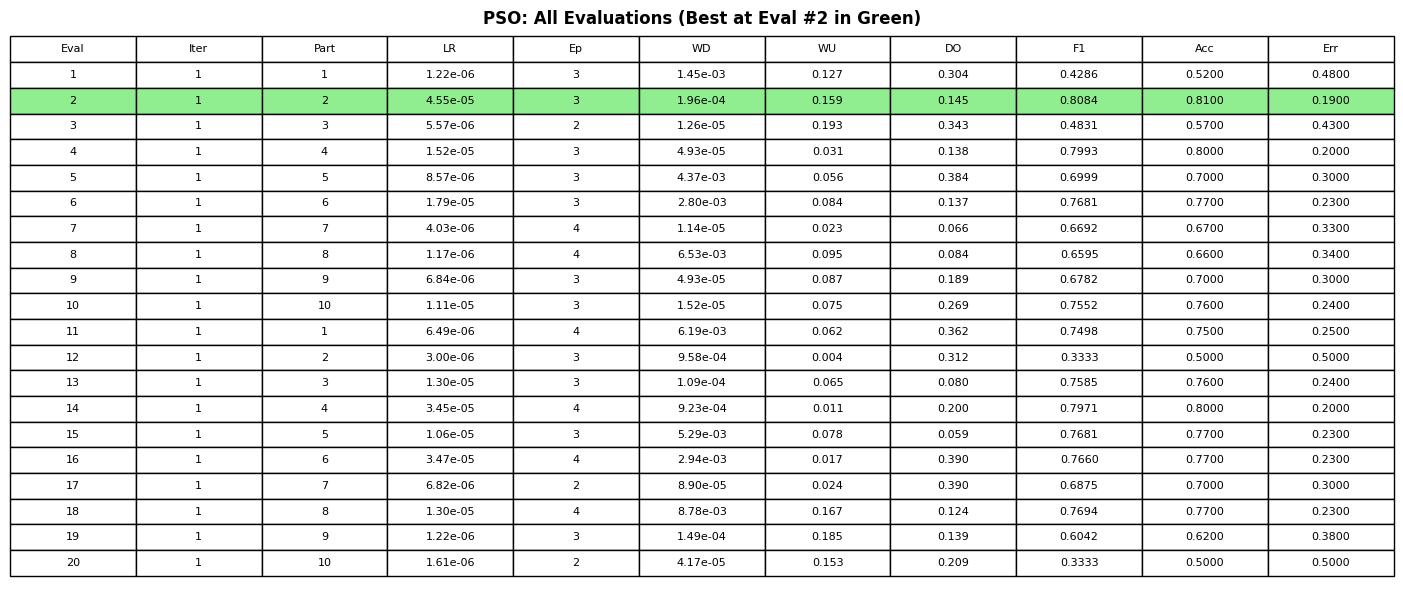

In [ ]:
# Cell 12d: PSO Results Table

import matplotlib.pyplot as plt
from matplotlib.table import Table

# Create results table
table_data = []
for r in pso_all_results:
    table_data.append([
        r['eval_num'], r['iteration'], r['particle'],
        f"{r['learning_rate']:.2e}", r['epochs'],
        f"{r['weight_decay']:.2e}", f"{r['warmup_ratio']:.3f}",
        f"{r['dropout_rate']:.3f}", f"{r['val_f1']:.4f}",
        f"{r['val_accuracy']:.4f}", f"{r['val_error']:.4f}"
    ])

fig, ax = plt.subplots(figsize=(14, max(5, len(table_data) * 0.3)))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data,
                  colLabels=['Eval', 'Iter', 'Part', 'LR', 'Ep', 'WD', 'WU', 'DO', 'F1', 'Acc', 'Err'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.3)

# Highlight best row
for i, r in enumerate(table_data):
    if r[0] == best_eval_num:
        for j in range(len(r)):
            table[(i+1, j)].set_facecolor('#90EE90')

plt.title(f'PSO: All Evaluations (Best at Eval #{best_eval_num} in Green)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

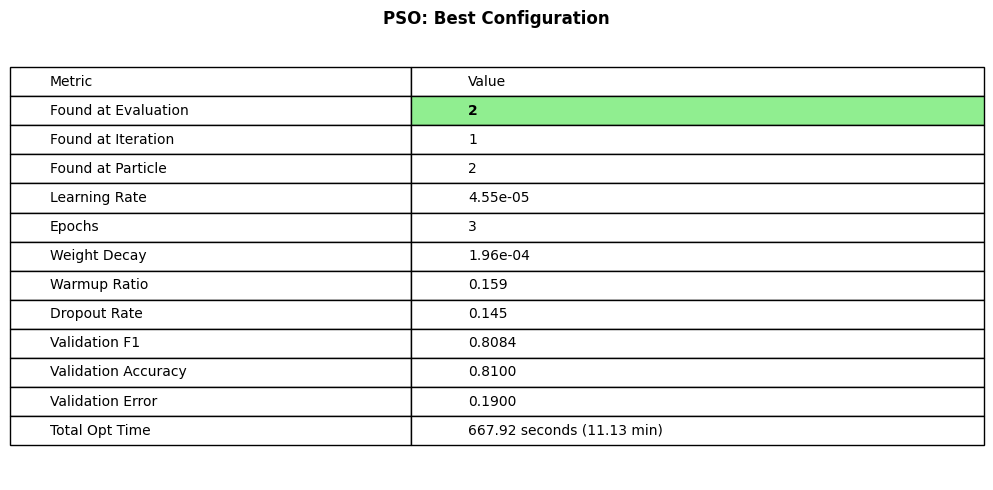

In [ ]:
# Cell 12e: PSO Best Configuration

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

best_data = [
    ['Metric', 'Value'],
    ['Found at Evaluation', best_eval_num],
    ['Found at Iteration', best_iteration],
    ['Found at Particle', best_particle],
    ['Learning Rate', f"{best_config['learning_rate']:.2e}"],
    ['Epochs', best_config['epochs']],
    ['Weight Decay', f"{best_config['weight_decay']:.2e}"],
    ['Warmup Ratio', f"{best_config['warmup_ratio']:.3f}"],
    ['Dropout Rate', f"{best_config['dropout_rate']:.3f}"],
    ['Validation F1', f"{best_config['val_f1']:.4f}"],
    ['Validation Accuracy', f"{best_config['val_accuracy']:.4f}"],
    ['Validation Error', f"{best_config['val_error']:.4f}"],
    ['Total Opt Time', f"{pso_time:.2f} seconds ({pso_time/60:.2f} min)"]
]

best_table = ax.table(cellText=best_data, cellLoc='left', loc='center', colWidths=[0.35, 0.5])
best_table.auto_set_font_size(False)
best_table.set_fontsize(10)
best_table.scale(1.2, 1.5)

# Highlight best eval row
best_table[(1, 1)].set_facecolor('#90EE90')
best_table[(1, 1)].set_text_props(weight='bold')

plt.title('PSO: Best Configuration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

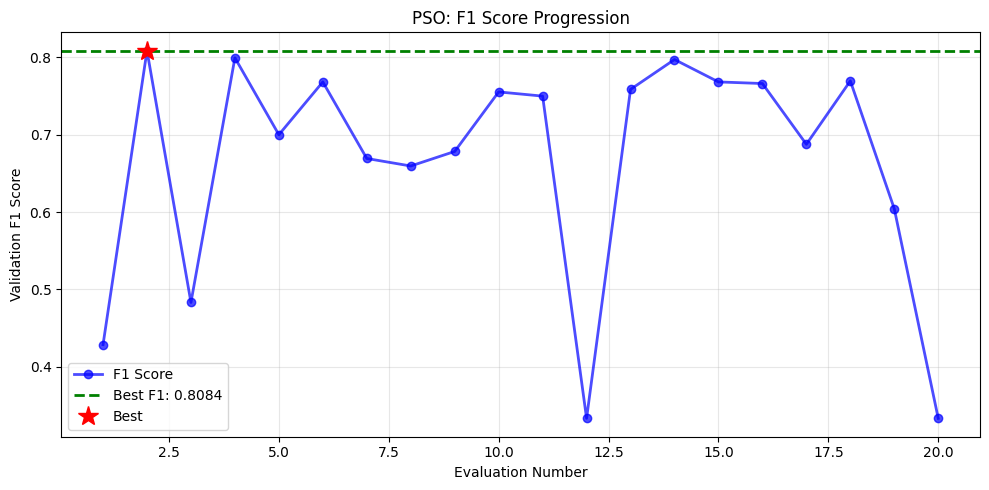

In [ ]:
# Cell 12f: PSO F1 Progression

fig, ax = plt.subplots(figsize=(10, 5))

evals = [r['eval_num'] for r in pso_all_results]
f1_scores = [r['val_f1'] for r in pso_all_results]

ax.plot(evals, f1_scores, 'b-o', linewidth=2, markersize=6, alpha=0.7, label='F1 Score')
ax.axhline(y=best_config['val_f1'], color='g', linestyle='--', linewidth=2,
           label=f"Best F1: {best_config['val_f1']:.4f}")
ax.plot(best_eval_num, best_config['val_f1'], 'r*', markersize=15, label='Best')

ax.set_xlabel('Evaluation Number')
ax.set_ylabel('Validation F1 Score')
ax.set_title('PSO: F1 Score Progression')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

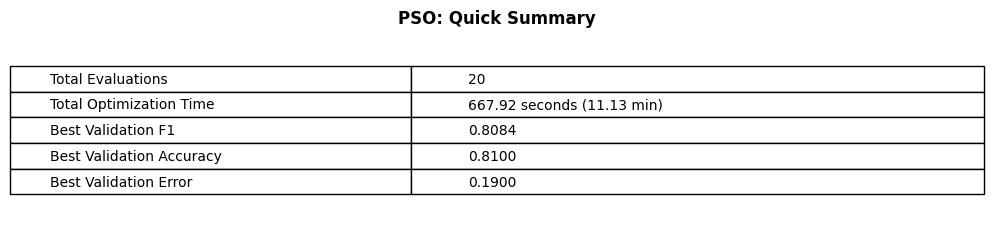


✅ PSO Optimization Complete!


In [ ]:
# Cell 12g: PSO Summary Table

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.axis('tight')
ax.axis('off')

summary_data = [
    ['Total Evaluations', len(pso_all_results)],
    ['Total Optimization Time', f"{pso_time:.2f} seconds ({pso_time/60:.2f} min)"],
    ['Best Validation F1', f"{best_config['val_f1']:.4f}"],
    ['Best Validation Accuracy', f"{best_config['val_accuracy']:.4f}"],
    ['Best Validation Error', f"{best_config['val_error']:.4f}"]
]

summary_table = ax.table(cellText=summary_data, cellLoc='left', loc='center', colWidths=[0.35, 0.5])
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10)
summary_table.scale(1.2, 1.5)

plt.title('PSO: Quick Summary', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ PSO Optimization Complete!")

In [ ]:
!pip install scikit-optimize -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
# Cell 13a: Bayesian Optimization - Setup

from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
import warnings
warnings.filterwarnings('ignore')

print("=" * 60)
print("BAYESIAN OPTIMIZATION")
print("=" * 60)

# Bayesian Optimization Settings
n_calls = 20  # Total evaluations (initial + iterations)
n_initial_points = 5  # Random initial points before Bayesian starts

print(f"Settings: {n_calls} total evaluations")
print(f"  - {n_initial_points} initial random evaluations")
print(f"  - {n_calls - n_initial_points} Bayesian-guided evaluations")

# Storage for results
bayesian_all_results = []
bayesian_eval_counter = 0

# Define search space for Bayesian (proper scale types)
bayesian_space = [
    Real(search_space["learning_rate"]["low"],
         search_space["learning_rate"]["high"],
         prior='log-uniform',
         name='learning_rate'),

    Integer(search_space["epochs"]["low"],
            search_space["epochs"]["high"],
            name='epochs'),

    Real(search_space["weight_decay"]["low"],
         search_space["weight_decay"]["high"],
         prior='log-uniform',
         name='weight_decay'),

    Real(search_space["warmup_ratio"]["low"],
         search_space["warmup_ratio"]["high"],
         name='warmup_ratio'),

    Real(search_space["dropout_rate"]["low"],
         search_space["dropout_rate"]["high"],
         name='dropout_rate')
]

print(f"\nSearch space defined for {len(bayesian_space)} parameters")

BAYESIAN OPTIMIZATION
Settings: 20 total evaluations
  - 5 initial random evaluations
  - 15 Bayesian-guided evaluations

Search space defined for 5 parameters


In [ ]:
# Cell 13b: Bayesian Objective Function

@use_named_args(bayesian_space)
def bayesian_objective(learning_rate, epochs, weight_decay, warmup_ratio, dropout_rate):
    """Objective function for Bayesian Optimization (minimize validation loss)"""
    global bayesian_eval_counter, bayesian_all_results

    bayesian_eval_counter += 1

    print(f"\n  🔄 Evaluation #{bayesian_eval_counter}/{n_calls}:")
    print(f"     lr={learning_rate:.2e}, epochs={epochs}, wd={weight_decay:.2e}, warmup={warmup_ratio:.3f}, dropout={dropout_rate:.3f}")

    try:
        # Use unified train_model
        result = train_model(
            epochs=epochs,
            lr=learning_rate,
            weight_decay=weight_decay,
            warmup_ratio=warmup_ratio,
            dropout_rate=dropout_rate,
            evaluate_on_test=False,
            verbose=False
        )

        # Store all results
        bayesian_all_results.append({
            "eval_num": bayesian_eval_counter,
            "learning_rate": learning_rate,
            "epochs": epochs,
            "weight_decay": weight_decay,
            "warmup_ratio": warmup_ratio,
            "dropout_rate": dropout_rate,
            "val_loss": result["val_loss"],
            "val_accuracy": result["val_accuracy"],
            "val_f1": result["val_f1"],
            "val_error": 1 - result["val_accuracy"],
            "training_time": result["training_time"],
            "gpu_memory_mb": result["gpu_memory_mb"]
        })

        print(f"     ✓ Results: F1={result['val_f1']:.4f}, Acc={result['val_accuracy']:.4f}, Loss={result['val_loss']:.6f}")

        return result["val_loss"]  # Minimize validation loss

    except Exception as e:
        print(f"     ✗ Error: {e}")
        return 999.0

In [ ]:
# Cell 13c: Run Bayesian Optimization

print("\n🔄 Running Bayesian Optimization...")
bayesian_start = time.time()

# Run Bayesian optimization
result = gp_minimize(
    func=bayesian_objective,
    dimensions=bayesian_space,
    n_calls=n_calls,
    n_initial_points=n_initial_points,
    acq_func='EI',  # Expected Improvement
    random_state=42,
    verbose=False
)

bayesian_time = time.time() - bayesian_start

# Find best configuration
best_config = min(bayesian_all_results, key=lambda x: x['val_loss'])  # Best by loss
best_eval_num = best_config['eval_num']

# Also find best by F1 (for display)
best_by_f1 = max(bayesian_all_results, key=lambda x: x['val_f1'])

print(f"\n{'='*60}")
print(f"Bayesian Complete! Time: {bayesian_time:.2f}s | Evals: {len(bayesian_all_results)}")
print(f"Best by Loss at Eval #{best_eval_num}: Loss={best_config['val_loss']:.6f}")
print(f"Best by F1 at Eval #{best_by_f1['eval_num']}: F1={best_by_f1['val_f1']:.4f}")
print(f"{'='*60}")

# Use best by F1 for display
best_config = best_by_f1
best_eval_num = best_config['eval_num']


🔄 Running Bayesian Optimization...

  🔄 Evaluation #1/20:
     lr=2.26e-05, epochs=2, wd=1.31e-02, warmup=0.119, dropout=0.206


2026-06-05 16:56:26,787 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:56:26,889 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:56:27,012 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

     ✓ Results: F1=0.7391, Acc=0.7400, Loss=0.581051

  🔄 Evaluation #2/20:
     lr=1.48e-06, epochs=3, wd=2.16e-04, warmup=0.029, dropout=0.278


2026-06-05 16:56:50,691 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:56:50,788 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 16:56:50,886 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

     ✓ Results: F1=0.7672, Acc=0.7700, Loss=0.641984

  🔄 Evaluation #20/20:
     lr=1.37e-05, epochs=3, wd=2.59e-02, warmup=0.200, dropout=0.308


2026-06-05 17:05:59,651 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:05:59,749 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:05:59,851 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

     ✓ Results: F1=0.7469, Acc=0.7500, Loss=0.576561

Bayesian Complete! Time: 605.37s | Evals: 20
Best by Loss at Eval #11: Loss=0.557505
Best by F1 at Eval #6: F1=0.8077


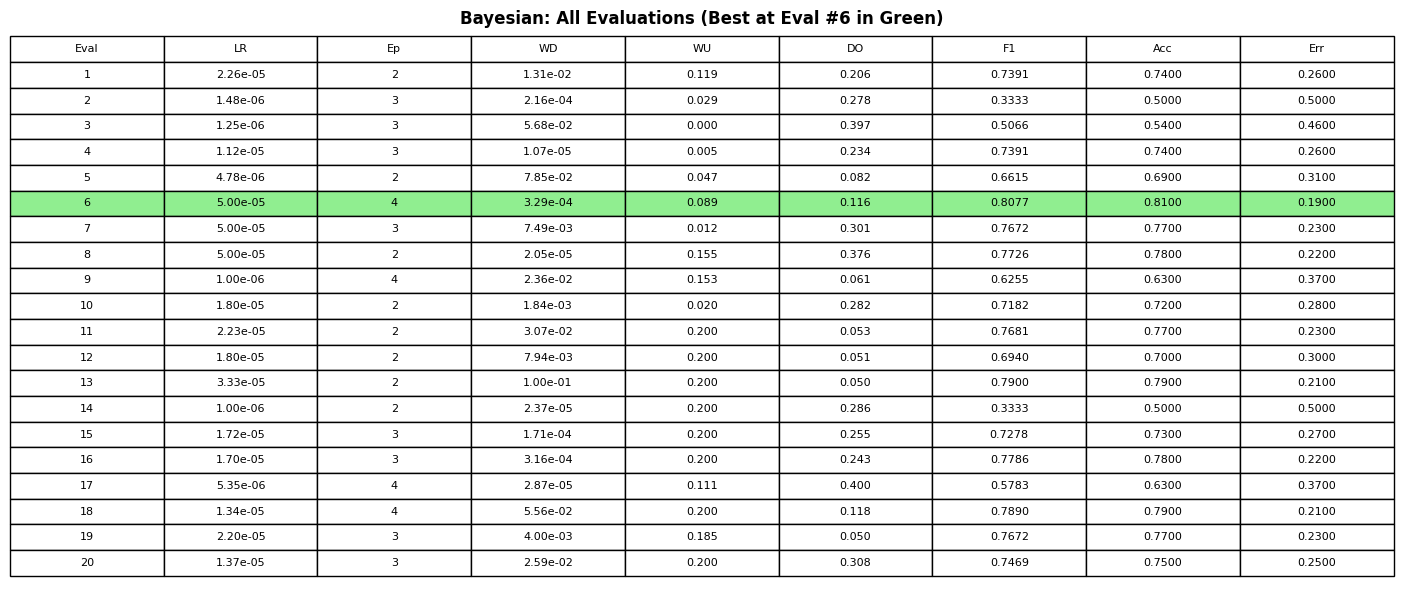

In [ ]:
# Cell 13d: Bayesian Results Table

import matplotlib.pyplot as plt
from matplotlib.table import Table

# Create results table
table_data = []
for r in bayesian_all_results:
    table_data.append([
        r['eval_num'],
        f"{r['learning_rate']:.2e}",
        r['epochs'],
        f"{r['weight_decay']:.2e}",
        f"{r['warmup_ratio']:.3f}",
        f"{r['dropout_rate']:.3f}",
        f"{r['val_f1']:.4f}",
        f"{r['val_accuracy']:.4f}",
        f"{r['val_error']:.4f}"
    ])

fig, ax = plt.subplots(figsize=(14, max(5, len(table_data) * 0.3)))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data,
                  colLabels=['Eval', 'LR', 'Ep', 'WD', 'WU', 'DO', 'F1', 'Acc', 'Err'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.3)

# Highlight best row
for i, r in enumerate(table_data):
    if int(r[0]) == best_eval_num:
        for j in range(len(r)):
            table[(i+1, j)].set_facecolor('#90EE90')

plt.title(f'Bayesian: All Evaluations (Best at Eval #{best_eval_num} in Green)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

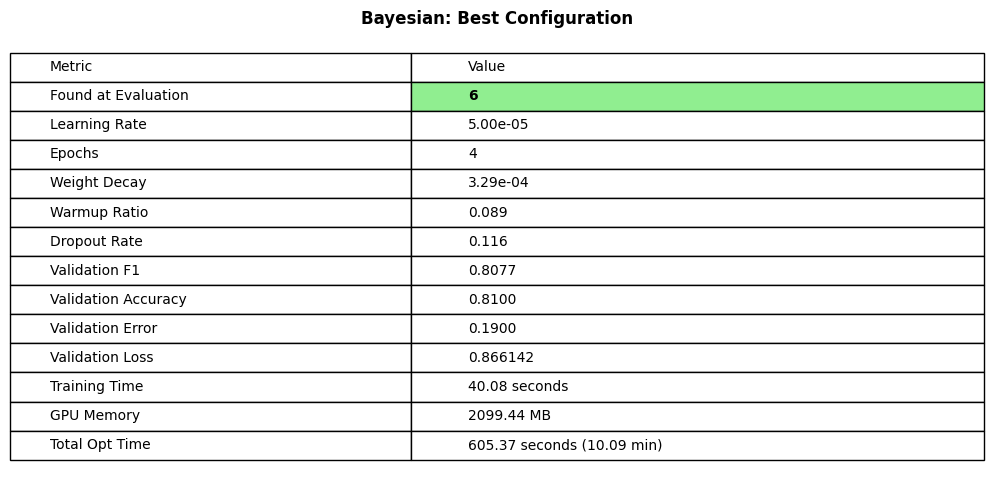

In [ ]:
# Cell 13e: Bayesian Best Configuration

fig, ax = plt.subplots(figsize=(10, 5))
ax.axis('tight')
ax.axis('off')

best_data = [
    ['Metric', 'Value'],
    ['Found at Evaluation', best_eval_num],
    ['Learning Rate', f"{best_config['learning_rate']:.2e}"],
    ['Epochs', best_config['epochs']],
    ['Weight Decay', f"{best_config['weight_decay']:.2e}"],
    ['Warmup Ratio', f"{best_config['warmup_ratio']:.3f}"],
    ['Dropout Rate', f"{best_config['dropout_rate']:.3f}"],
    ['Validation F1', f"{best_config['val_f1']:.4f}"],
    ['Validation Accuracy', f"{best_config['val_accuracy']:.4f}"],
    ['Validation Error', f"{best_config['val_error']:.4f}"],
    ['Validation Loss', f"{best_config['val_loss']:.6f}"],
    ['Training Time', f"{best_config['training_time']:.2f} seconds"],
    ['GPU Memory', f"{best_config['gpu_memory_mb']:.2f} MB"],
    ['Total Opt Time', f"{bayesian_time:.2f} seconds ({bayesian_time/60:.2f} min)"]
]

best_table = ax.table(cellText=best_data, cellLoc='left', loc='center', colWidths=[0.35, 0.5])
best_table.auto_set_font_size(False)
best_table.set_fontsize(10)
best_table.scale(1.2, 1.5)

# Highlight best eval row
best_table[(1, 1)].set_facecolor('#90EE90')
best_table[(1, 1)].set_text_props(weight='bold')

plt.title('Bayesian: Best Configuration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

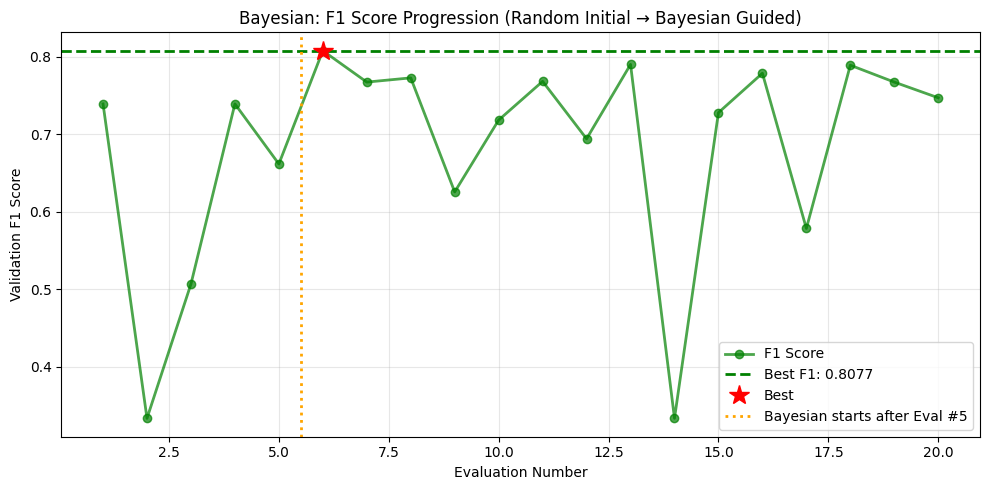

In [ ]:
# Cell 13f: Bayesian F1 Progression

fig, ax = plt.subplots(figsize=(10, 5))

evals = [r['eval_num'] for r in bayesian_all_results]
f1_scores = [r['val_f1'] for r in bayesian_all_results]

ax.plot(evals, f1_scores, 'g-o', linewidth=2, markersize=6, alpha=0.7, label='F1 Score')
ax.axhline(y=best_config['val_f1'], color='g', linestyle='--', linewidth=2,
           label=f"Best F1: {best_config['val_f1']:.4f}")
ax.plot(best_eval_num, best_config['val_f1'], 'r*', markersize=15, label='Best')

# Mark initial random points
ax.axvline(x=n_initial_points + 0.5, color='orange', linestyle=':', linewidth=2,
           label=f'Bayesian starts after Eval #{n_initial_points}')

ax.set_xlabel('Evaluation Number')
ax.set_ylabel('Validation F1 Score')
ax.set_title('Bayesian: F1 Score Progression (Random Initial → Bayesian Guided)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

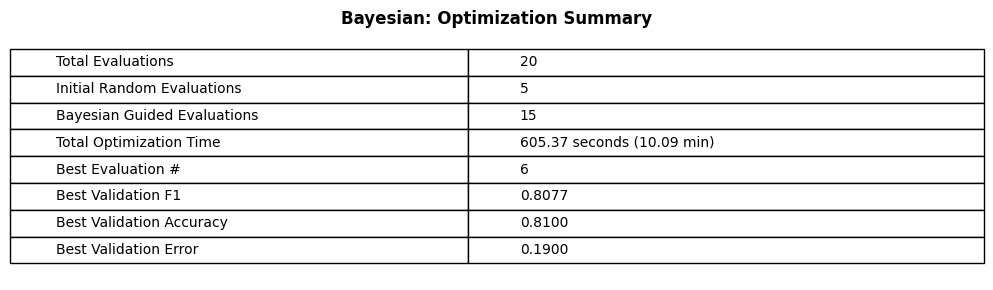


✅ Bayesian Optimization Complete!
   Best F1: 0.8077
   Found at evaluation #6


In [ ]:
# Cell 13g: Bayesian Summary Table

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('tight')
ax.axis('off')

summary_data = [
    ['Total Evaluations', len(bayesian_all_results)],
    ['Initial Random Evaluations', n_initial_points],
    ['Bayesian Guided Evaluations', n_calls - n_initial_points],
    ['Total Optimization Time', f"{bayesian_time:.2f} seconds ({bayesian_time/60:.2f} min)"],
    ['Best Evaluation #', best_eval_num],
    ['Best Validation F1', f"{best_config['val_f1']:.4f}"],
    ['Best Validation Accuracy', f"{best_config['val_accuracy']:.4f}"],
    ['Best Validation Error', f"{best_config['val_error']:.4f}"]
]

summary_table = ax.table(cellText=summary_data, cellLoc='left', loc='center', colWidths=[0.4, 0.45])
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10)
summary_table.scale(1.2, 1.5)

plt.title('Bayesian: Optimization Summary', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Bayesian Optimization Complete!")
print(f"   Best F1: {best_config['val_f1']:.4f}")
print(f"   Found at evaluation #{best_eval_num}")

In [ ]:
# Cell 14a: Genetic Algorithm - Setup

from sklearn.base import clone
import random

print("=" * 60)
print("GENETIC ALGORITHM (GA)")
print("=" * 60)

# Genetic Algorithm Settings
population_size = 5
n_generations = 4  # 5 × 4 = 20 evaluations
mutation_rate = 0.2
crossover_rate = 0.8

print(f"Settings: {population_size} population × {n_generations} generations = {population_size * n_generations} evaluations")
print(f"  - Mutation Rate: {mutation_rate}")
print(f"  - Crossover Rate: {crossover_rate}")

# Storage for results
ga_all_results = []
ga_eval_counter = 0

# Helper functions for GA
def create_individual():
    """Create a random individual (hyperparameter set)"""
    individual = []
    for name in param_names:
        low = search_space[name]["low"]
        high = search_space[name]["high"]
        scale = search_space[name]["scale"]

        if scale == "log":
            # Sample in log space
            log_low = np.log10(low)
            log_high = np.log10(high)
            value = 10 ** np.random.uniform(log_low, log_high)
        elif scale == "int":
            value = np.random.randint(low, high + 1)
        else:  # linear
            value = np.random.uniform(low, high)

        individual.append(value)

    return individual

def decode_individual(individual):
    """Convert individual list to dictionary with proper types"""
    params = {}
    for i, name in enumerate(param_names):
        value = individual[i]
        scale = search_space[name]["scale"]

        if scale == "int":
            params[name] = int(round(value))
        else:
            params[name] = value

    # Ensure bounds
    for name in param_names:
        low = search_space[name]["low"]
        high = search_space[name]["high"]
        params[name] = max(low, min(high, params[name]))

    return params

GENETIC ALGORITHM (GA)
Settings: 5 population × 4 generations = 20 evaluations
  - Mutation Rate: 0.2
  - Crossover Rate: 0.8


In [ ]:
# Cell 14b: Genetic Operators (Crossover, Mutation, Selection)

def crossover(parent1, parent2):
    """Single-point crossover between two parents"""
    if np.random.random() > crossover_rate:
        return parent1.copy(), parent2.copy()

    crossover_point = np.random.randint(1, len(parent1))
    child1 = parent1[:crossover_point] + parent2[crossover_point:]
    child2 = parent2[:crossover_point] + parent1[crossover_point:]

    return child1, child2

def mutate(individual):
    """Mutate an individual with given mutation rate"""
    for i in range(len(individual)):
        if np.random.random() < mutation_rate:
            name = param_names[i]
            low = search_space[name]["low"]
            high = search_space[name]["high"]
            scale = search_space[name]["scale"]

            if scale == "log":
                log_low = np.log10(low)
                log_high = np.log10(high)
                individual[i] = 10 ** np.random.uniform(log_low, log_high)
            elif scale == "int":
                # Add small mutation and clamp
                delta = np.random.randint(-1, 2)
                individual[i] = int(round(individual[i] + delta))
                individual[i] = max(low, min(high, individual[i]))
            else:  # linear
                delta = np.random.uniform(-0.1, 0.1) * (high - low)
                individual[i] += delta
                individual[i] = max(low, min(high, individual[i]))

    return individual

def tournament_selection(population, fitness_scores, tournament_size=3):
    """Select parent using tournament selection"""
    selected_indices = np.random.choice(len(population), tournament_size, replace=False)
    best_idx = selected_indices[np.argmin([fitness_scores[i] for i in selected_indices])]
    return population[best_idx].copy()

In [ ]:
# Cell 14c: Genetic Algorithm - Evaluate Population

def evaluate_individual(individual, generation, individual_idx):
    """Evaluate a single individual and return fitness (validation loss)"""
    global ga_eval_counter, ga_all_results

    ga_eval_counter += 1
    params = decode_individual(individual)

    print(f"\n  🔄 Eval #{ga_eval_counter} (Gen {generation+1}, Individual {individual_idx+1}):")
    print(f"     lr={params['learning_rate']:.2e}, epochs={params['epochs']}, "
          f"wd={params['weight_decay']:.2e}, warmup={params['warmup_ratio']:.3f}, "
          f"dropout={params['dropout_rate']:.3f}")

    try:
        result = train_model(
            epochs=params['epochs'],
            lr=params['learning_rate'],
            weight_decay=params['weight_decay'],
            warmup_ratio=params['warmup_ratio'],
            dropout_rate=params['dropout_rate'],
            evaluate_on_test=False,
            verbose=False
        )

        ga_all_results.append({
            "eval_num": ga_eval_counter,
            "generation": generation + 1,
            "individual": individual_idx + 1,
            "learning_rate": params['learning_rate'],
            "epochs": params['epochs'],
            "weight_decay": params['weight_decay'],
            "warmup_ratio": params['warmup_ratio'],
            "dropout_rate": params['dropout_rate'],
            "val_loss": result["val_loss"],
            "val_accuracy": result["val_accuracy"],
            "val_f1": result["val_f1"],
            "val_error": 1 - result["val_accuracy"],
            "training_time": result["training_time"],
            "gpu_memory_mb": result["gpu_memory_mb"]
        })

        print(f"     ✓ F1={result['val_f1']:.4f}, Acc={result['val_accuracy']:.4f}, Loss={result['val_loss']:.6f}")

        return result["val_loss"]  # Minimize validation loss

    except Exception as e:
        print(f"     ✗ Error: {e}")
        return 999.0

def evaluate_population(population, generation):
    """Evaluate all individuals in population"""
    fitness_scores = []
    for i, individual in enumerate(population):
        fitness = evaluate_individual(individual, generation, i)
        fitness_scores.append(fitness)
    return fitness_scores

In [ ]:
# Cell 14d: Run Genetic Algorithm (FIXED)

print("\n🔄 Running Genetic Algorithm...")
ga_start = time.time()

# Initialize population
population = [create_individual() for _ in range(population_size)]

# Track best over generations
best_individual_overall = None
best_fitness_overall = float('inf')
best_generation = 0
best_individual_idx = 0
best_f1_score = 0  # Track F1 for display

# Store fitness scores for each individual
all_fitness_scores = []

# Evolution loop
for generation in range(n_generations):
    print(f"\n{'='*40}")
    print(f"GENERATION {generation + 1}/{n_generations}")
    print(f"{'='*40}")

    # Evaluate population
    fitness_scores = evaluate_population(population, generation)
    all_fitness_scores.append(fitness_scores)

    # Track best
    current_best_idx = np.argmin(fitness_scores)
    current_best_fitness = fitness_scores[current_best_idx]

    if current_best_fitness < best_fitness_overall:
        best_fitness_overall = current_best_fitness
        best_individual_overall = population[current_best_idx].copy()
        best_generation = generation
        best_individual_idx = current_best_idx

        # Get the F1 score from stored results
        # Find the most recent evaluation for this individual
        best_params = decode_individual(best_individual_overall)
        matching_results = [r for r in ga_all_results
                           if r['generation'] == generation + 1
                           and r['individual'] == current_best_idx + 1]
        if matching_results:
            best_f1_score = matching_results[0]['val_f1']
            print(f"  ⭐ New best found! F1={best_f1_score:.4f}")

    # Create next generation
    if generation < n_generations - 1:  # Don't create next gen after last
        next_population = []

        # Elitism: keep the best individual
        next_population.append(best_individual_overall.copy())

        # Create offspring until population is filled
        while len(next_population) < population_size:
            # Selection
            parent1 = tournament_selection(population, fitness_scores)
            parent2 = tournament_selection(population, fitness_scores)

            # Crossover
            child1, child2 = crossover(parent1, parent2)

            # Mutation
            child1 = mutate(child1)
            child2 = mutate(child2)

            next_population.append(child1)
            if len(next_population) < population_size:
                next_population.append(child2)

        population = next_population

ga_time = time.time() - ga_start

# Find best configuration from all results
best_config = max(ga_all_results, key=lambda x: x['val_f1'])
best_eval_num = best_config['eval_num']
best_generation_found = best_config['generation']
best_individual_found = best_config['individual']

print(f"\n{'='*60}")
print(f"GA Complete! Time: {ga_time:.2f}s | Evals: {len(ga_all_results)}")
print(f"Best F1: {best_config['val_f1']:.4f} at Generation {best_generation_found}, Individual {best_individual_found}")
print(f"{'='*60}")


🔄 Running Genetic Algorithm...

GENERATION 1/4

  🔄 Eval #6 (Gen 1, Individual 1):
     lr=6.66e-06, epochs=3, wd=1.10e-02, warmup=0.106, dropout=0.302


2026-06-05 17:13:45,002 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:13:45,101 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:13:45,201 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

     ✓ F1=0.7199, Acc=0.7300, Loss=0.671061

  🔄 Eval #7 (Gen 1, Individual 2):
     lr=1.28e-06, epochs=4, wd=1.02e-04, warmup=0.143, dropout=0.363


2026-06-05 17:14:18,558 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:14:18,665 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:14:18,763 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

     ✓ F1=0.7480, Acc=0.7500, Loss=0.570214

  🔄 Eval #25 (Gen 4, Individual 5):
     lr=7.40e-06, epochs=4, wd=1.32e-05, warmup=0.173, dropout=0.174


2026-06-05 17:26:13,424 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:26:13,521 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/config.json "HTTP/1.1 200 OK"
2026-06-05 17:26:13,621 - httpx - INFO - HTTP Request: HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/model.safetensors "HTTP/1.1 302 Found"


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

     ✓ F1=0.7254, Acc=0.7300, Loss=0.595215
  ⭐ New best found! F1=0.7480

GA Complete! Time: 790.73s | Evals: 25
Best F1: 0.8077 at Generation 2, Individual 4


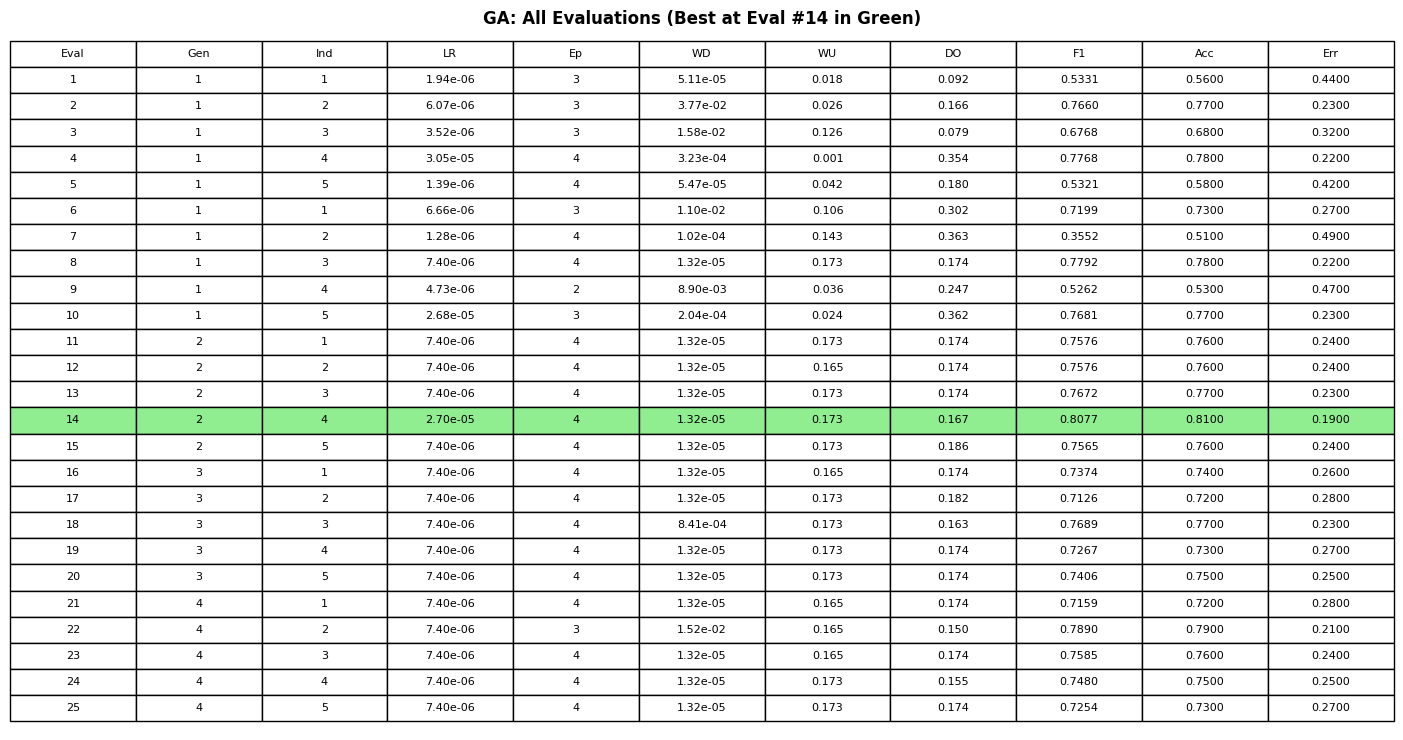

In [ ]:
# Cell 14e: GA Results Table

import matplotlib.pyplot as plt
from matplotlib.table import Table

# Create results table
table_data = []
for r in ga_all_results:
    table_data.append([
        r['eval_num'],
        r['generation'],
        r['individual'],
        f"{r['learning_rate']:.2e}",
        r['epochs'],
        f"{r['weight_decay']:.2e}",
        f"{r['warmup_ratio']:.3f}",
        f"{r['dropout_rate']:.3f}",
        f"{r['val_f1']:.4f}",
        f"{r['val_accuracy']:.4f}",
        f"{r['val_error']:.4f}"
    ])

fig, ax = plt.subplots(figsize=(14, max(5, len(table_data) * 0.3)))
ax.axis('tight')
ax.axis('off')

table = ax.table(cellText=table_data,
                  colLabels=['Eval', 'Gen', 'Ind', 'LR', 'Ep', 'WD', 'WU', 'DO', 'F1', 'Acc', 'Err'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.3)

# Highlight best row
for i, r in enumerate(table_data):
    if int(r[0]) == best_eval_num:
        for j in range(len(r)):
            table[(i+1, j)].set_facecolor('#90EE90')

plt.title(f'GA: All Evaluations (Best at Eval #{best_eval_num} in Green)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

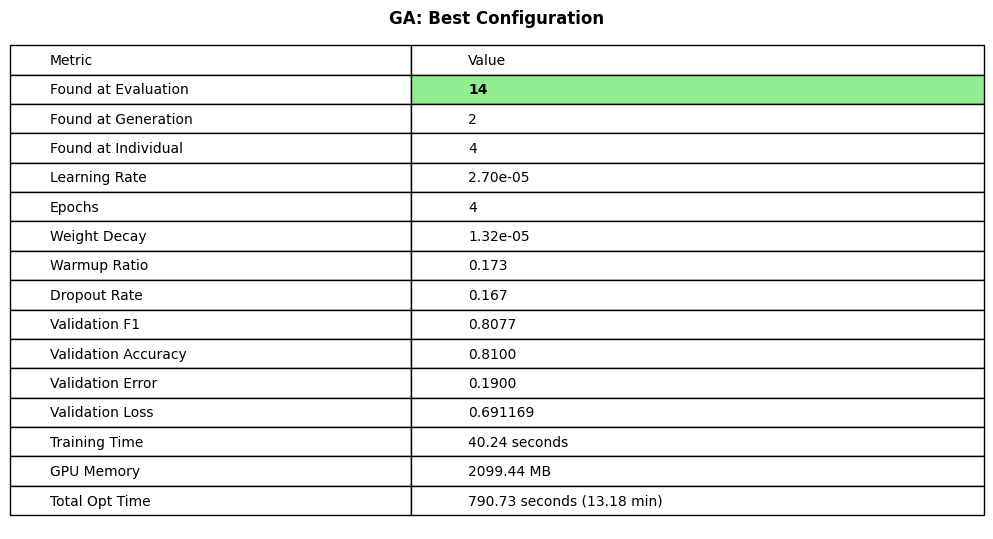

In [ ]:
# Cell 14f: GA Best Configuration

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.axis('tight')
ax.axis('off')

best_data = [
    ['Metric', 'Value'],
    ['Found at Evaluation', best_eval_num],
    ['Found at Generation', best_generation_found],
    ['Found at Individual', best_individual_found],
    ['Learning Rate', f"{best_config['learning_rate']:.2e}"],
    ['Epochs', best_config['epochs']],
    ['Weight Decay', f"{best_config['weight_decay']:.2e}"],
    ['Warmup Ratio', f"{best_config['warmup_ratio']:.3f}"],
    ['Dropout Rate', f"{best_config['dropout_rate']:.3f}"],
    ['Validation F1', f"{best_config['val_f1']:.4f}"],
    ['Validation Accuracy', f"{best_config['val_accuracy']:.4f}"],
    ['Validation Error', f"{best_config['val_error']:.4f}"],
    ['Validation Loss', f"{best_config['val_loss']:.6f}"],
    ['Training Time', f"{best_config['training_time']:.2f} seconds"],
    ['GPU Memory', f"{best_config['gpu_memory_mb']:.2f} MB"],
    ['Total Opt Time', f"{ga_time:.2f} seconds ({ga_time/60:.2f} min)"]
]

best_table = ax.table(cellText=best_data, cellLoc='left', loc='center', colWidths=[0.35, 0.5])
best_table.auto_set_font_size(False)
best_table.set_fontsize(10)
best_table.scale(1.2, 1.5)

# Highlight best eval row
best_table[(1, 1)].set_facecolor('#90EE90')
best_table[(1, 1)].set_text_props(weight='bold')

plt.title('GA: Best Configuration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

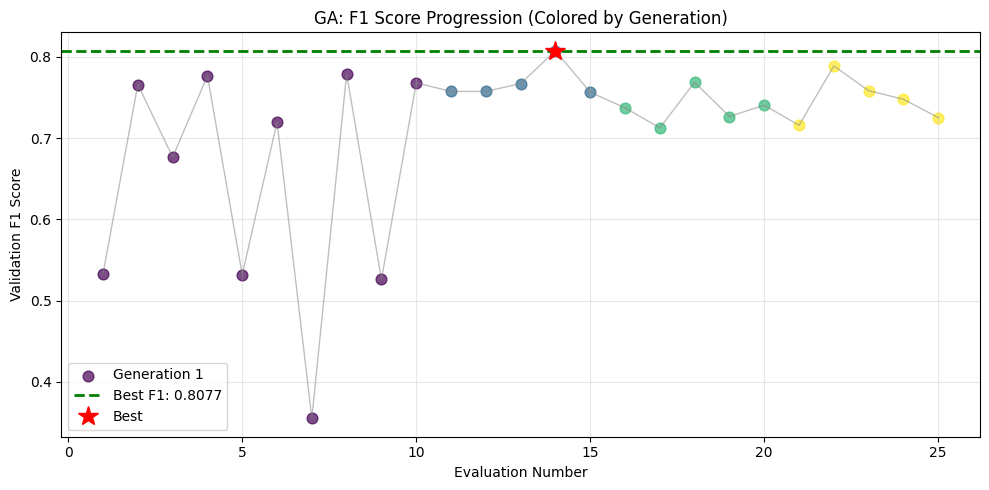

In [ ]:
# Cell 14g: GA F1 Progression

fig, ax = plt.subplots(figsize=(10, 5))

evals = [r['eval_num'] for r in ga_all_results]
f1_scores = [r['val_f1'] for r in ga_all_results]
generations = [r['generation'] for r in ga_all_results]

# Color by generation
colors = plt.cm.viridis(np.linspace(0, 1, n_generations))
for gen in range(1, n_generations + 1):
    gen_indices = [i for i, g in enumerate(generations) if g == gen]
    ax.scatter([evals[i] for i in gen_indices], [f1_scores[i] for i in gen_indices],
               color=colors[gen-1], s=60, alpha=0.7, label=f'Generation {gen}' if gen == 1 else "")

# Line connecting points
ax.plot(evals, f1_scores, 'gray', linewidth=1, alpha=0.5)
ax.axhline(y=best_config['val_f1'], color='g', linestyle='--', linewidth=2,
           label=f"Best F1: {best_config['val_f1']:.4f}")
ax.plot(best_eval_num, best_config['val_f1'], 'r*', markersize=15, label='Best')

ax.set_xlabel('Evaluation Number')
ax.set_ylabel('Validation F1 Score')
ax.set_title('GA: F1 Score Progression (Colored by Generation)')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

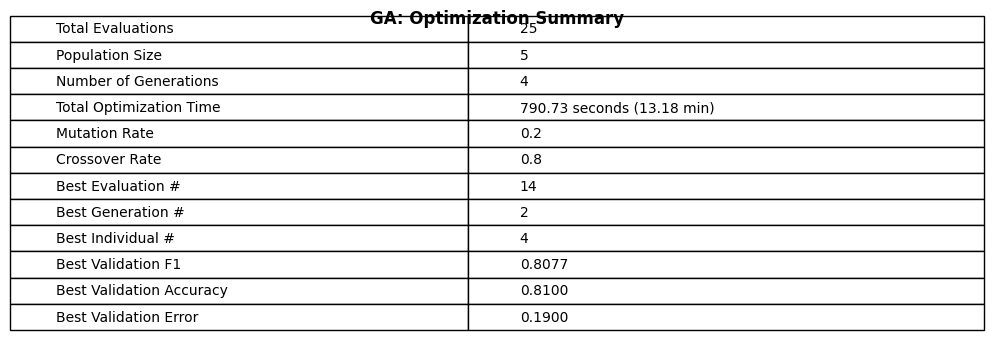


✅ Genetic Algorithm Complete!
   Best F1: 0.8077
   Found at Generation 2, Individual 4


In [ ]:
# Cell 14h: GA Summary Table

fig, ax = plt.subplots(figsize=(10, 3.5))
ax.axis('tight')
ax.axis('off')

summary_data = [
    ['Total Evaluations', len(ga_all_results)],
    ['Population Size', population_size],
    ['Number of Generations', n_generations],
    ['Total Optimization Time', f"{ga_time:.2f} seconds ({ga_time/60:.2f} min)"],
    ['Mutation Rate', f"{mutation_rate}"],
    ['Crossover Rate', f"{crossover_rate}"],
    ['Best Evaluation #', best_eval_num],
    ['Best Generation #', best_generation_found],
    ['Best Individual #', best_individual_found],
    ['Best Validation F1', f"{best_config['val_f1']:.4f}"],
    ['Best Validation Accuracy', f"{best_config['val_accuracy']:.4f}"],
    ['Best Validation Error', f"{best_config['val_error']:.4f}"]
]

summary_table = ax.table(cellText=summary_data, cellLoc='left', loc='center', colWidths=[0.4, 0.45])
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(10)
summary_table.scale(1.2, 1.5)

plt.title('GA: Optimization Summary', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Genetic Algorithm Complete!")
print(f"   Best F1: {best_config['val_f1']:.4f}")
print(f"   Found at Generation {best_generation_found}, Individual {best_individual_found}")

In [ ]:
# Cell 15a: Collect and Prepare Comparison Data

print("=" * 60)
print("COMPARING ALL THREE OPTIMIZATION ALGORITHMS")
print("=" * 60)

# Extract best results from each algorithm
pso_best = max(pso_all_results, key=lambda x: x['val_f1'])
bayesian_best = max(bayesian_all_results, key=lambda x: x['val_f1'])
ga_best = max(ga_all_results, key=lambda x: x['val_f1'])

# Create comparison dataframe
comparison_data = {
    "Algorithm": ["PSO", "Bayesian", "Genetic Algorithm"],
    "Best F1 Score": [
        pso_best['val_f1'],
        bayesian_best['val_f1'],
        ga_best['val_f1']
    ],
    "Best Accuracy": [
        pso_best['val_accuracy'],
        bayesian_best['val_accuracy'],
        ga_best['val_accuracy']
    ],
    "Best Validation Error": [
        pso_best['val_error'],
        bayesian_best['val_error'],
        ga_best['val_error']
    ],
    "Best Validation Loss": [
        pso_best['val_loss'],
        bayesian_best['val_loss'],
        ga_best['val_loss']
    ],
    "Evaluation Found": [
        pso_best['eval_num'],
        bayesian_best['eval_num'],
        ga_best['eval_num']
    ],
    "Training Time (s)": [
        pso_best['training_time'],
        bayesian_best['training_time'],
        ga_best['training_time']
    ],
    "GPU Memory (MB)": [
        pso_best['gpu_memory_mb'],
        bayesian_best['gpu_memory_mb'],
        ga_best['gpu_memory_mb']
    ]
}

# Find overall best
overall_best = max([pso_best, bayesian_best, ga_best], key=lambda x: x['val_f1'])
overall_algorithm = "PSO" if overall_best == pso_best else "Bayesian" if overall_best == bayesian_best else "Genetic Algorithm"

print(f"\n🏆 OVERALL BEST ALGORITHM: {overall_algorithm}")
print(f"   Best F1 Score: {overall_best['val_f1']:.4f}")
print(f"   Found at evaluation #{overall_best['eval_num']}")

COMPARING ALL THREE OPTIMIZATION ALGORITHMS

🏆 OVERALL BEST ALGORITHM: PSO
   Best F1 Score: 0.8084
   Found at evaluation #2


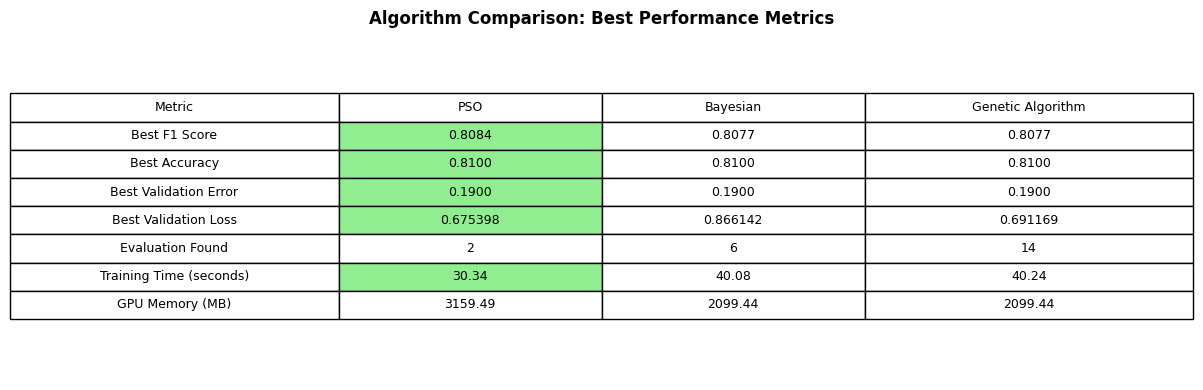

In [ ]:
# Cell 15b: Comparison Table

import matplotlib.pyplot as plt
from matplotlib.table import Table

fig, ax = plt.subplots(figsize=(12, 4))
ax.axis('tight')
ax.axis('off')

# Prepare table data
table_data = [
    ['Metric', 'PSO', 'Bayesian', 'Genetic Algorithm'],
    ['Best F1 Score',
     f"{pso_best['val_f1']:.4f}",
     f"{bayesian_best['val_f1']:.4f}",
     f"{ga_best['val_f1']:.4f}"],
    ['Best Accuracy',
     f"{pso_best['val_accuracy']:.4f}",
     f"{bayesian_best['val_accuracy']:.4f}",
     f"{ga_best['val_accuracy']:.4f}"],
    ['Best Validation Error',
     f"{pso_best['val_error']:.4f}",
     f"{bayesian_best['val_error']:.4f}",
     f"{ga_best['val_error']:.4f}"],
    ['Best Validation Loss',
     f"{pso_best['val_loss']:.6f}",
     f"{bayesian_best['val_loss']:.6f}",
     f"{ga_best['val_loss']:.6f}"],
    ['Evaluation Found',
     pso_best['eval_num'],
     bayesian_best['eval_num'],
     ga_best['eval_num']],
    ['Training Time (seconds)',
     f"{pso_best['training_time']:.2f}",
     f"{bayesian_best['training_time']:.2f}",
     f"{ga_best['training_time']:.2f}"],
    ['GPU Memory (MB)',
     f"{pso_best['gpu_memory_mb']:.2f}",
     f"{bayesian_best['gpu_memory_mb']:.2f}",
     f"{ga_best['gpu_memory_mb']:.2f}"]
]

table = ax.table(cellText=table_data, cellLoc='center', loc='center', colWidths=[0.25, 0.2, 0.2, 0.25])
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1.2, 1.5)

# Highlight best in each row
for i in range(1, len(table_data)):
    row_values = [table_data[i][1], table_data[i][2], table_data[i][3]]
    if 'F1' in table_data[i][0] or 'Accuracy' in table_data[i][0]:
        # Higher is better
        best_idx = row_values.index(max(row_values)) + 1
        table[(i, best_idx)].set_facecolor('#90EE90')
    elif 'Error' in table_data[i][0] or 'Loss' in table_data[i][0] or 'Time' in table_data[i][0]:
        # Lower is better
        # Convert to float for comparison
        float_values = [float(v.split()[0]) if ' ' in v else float(v) for v in row_values]
        best_idx = float_values.index(min(float_values)) + 1
        table[(i, best_idx)].set_facecolor('#90EE90')

plt.title('Algorithm Comparison: Best Performance Metrics', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

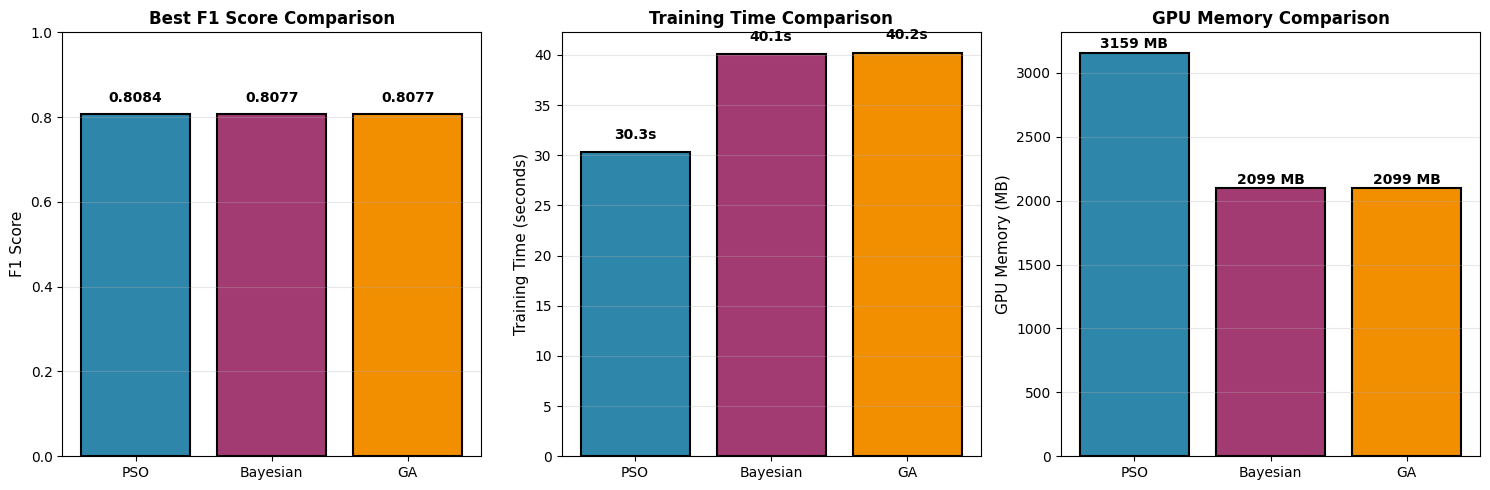

In [ ]:
# Cell 15c: Bar Chart Comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. F1 Score Comparison
algorithms = ['PSO', 'Bayesian', 'GA']
f1_scores = [pso_best['val_f1'], bayesian_best['val_f1'], ga_best['val_f1']]
colors_bar = ['#2E86AB', '#A23B72', '#F18F01']

bars1 = axes[0].bar(algorithms, f1_scores, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[0].set_ylim([0, 1])
axes[0].set_ylabel('F1 Score', fontsize=11)
axes[0].set_title('Best F1 Score Comparison', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

for bar, score in zip(bars1, f1_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 2. Training Time Comparison
train_times = [pso_best['training_time'], bayesian_best['training_time'], ga_best['training_time']]
bars2 = axes[1].bar(algorithms, train_times, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[1].set_ylabel('Training Time (seconds)', fontsize=11)
axes[1].set_title('Training Time Comparison', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

for bar, time_val in zip(bars2, train_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{time_val:.1f}s', ha='center', va='bottom', fontsize=10, fontweight='bold')

# 3. GPU Memory Comparison
gpu_memory = [pso_best['gpu_memory_mb'], bayesian_best['gpu_memory_mb'], ga_best['gpu_memory_mb']]
bars3 = axes[2].bar(algorithms, gpu_memory, color=colors_bar, edgecolor='black', linewidth=1.5)
axes[2].set_ylabel('GPU Memory (MB)', fontsize=11)
axes[2].set_title('GPU Memory Comparison', fontsize=12, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)

for bar, mem in zip(bars3, gpu_memory):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{mem:.0f} MB', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

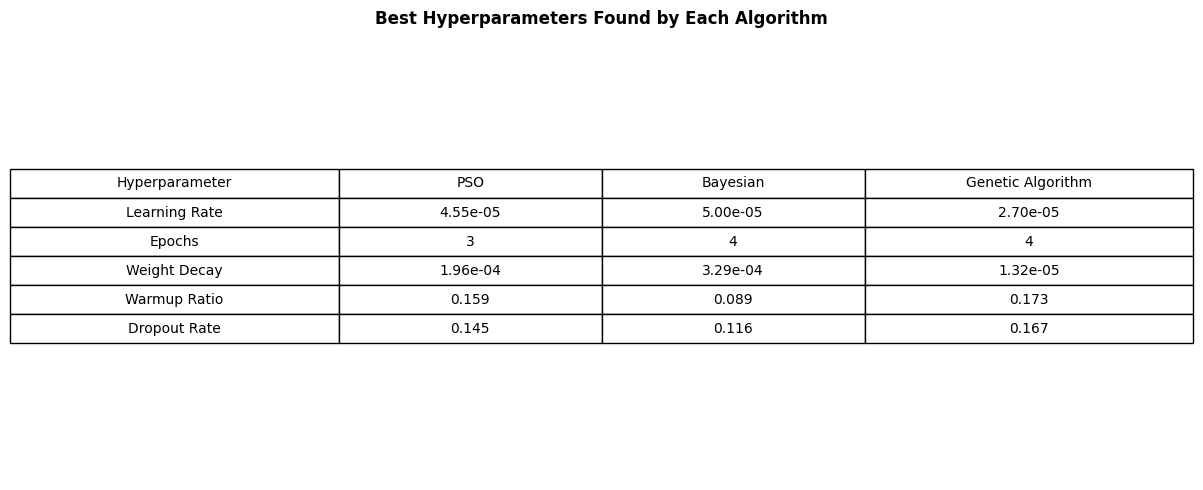

In [ ]:
# Cell 15d: Best Hyperparameters Comparison

fig, ax = plt.subplots(figsize=(12, 5))
ax.axis('tight')
ax.axis('off')

hyper_data = [
    ['Hyperparameter', 'PSO', 'Bayesian', 'Genetic Algorithm'],
    ['Learning Rate',
     f"{pso_best['learning_rate']:.2e}",
     f"{bayesian_best['learning_rate']:.2e}",
     f"{ga_best['learning_rate']:.2e}"],
    ['Epochs',
     pso_best['epochs'],
     bayesian_best['epochs'],
     ga_best['epochs']],
    ['Weight Decay',
     f"{pso_best['weight_decay']:.2e}",
     f"{bayesian_best['weight_decay']:.2e}",
     f"{ga_best['weight_decay']:.2e}"],
    ['Warmup Ratio',
     f"{pso_best['warmup_ratio']:.3f}",
     f"{bayesian_best['warmup_ratio']:.3f}",
     f"{ga_best['warmup_ratio']:.3f}"],
    ['Dropout Rate',
     f"{pso_best['dropout_rate']:.3f}",
     f"{bayesian_best['dropout_rate']:.3f}",
     f"{ga_best['dropout_rate']:.3f}"]
]

hyper_table = ax.table(cellText=hyper_data, cellLoc='center', loc='center', colWidths=[0.25, 0.2, 0.2, 0.25])
hyper_table.auto_set_font_size(False)
hyper_table.set_fontsize(10)
hyper_table.scale(1.2, 1.5)

plt.title('Best Hyperparameters Found by Each Algorithm', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

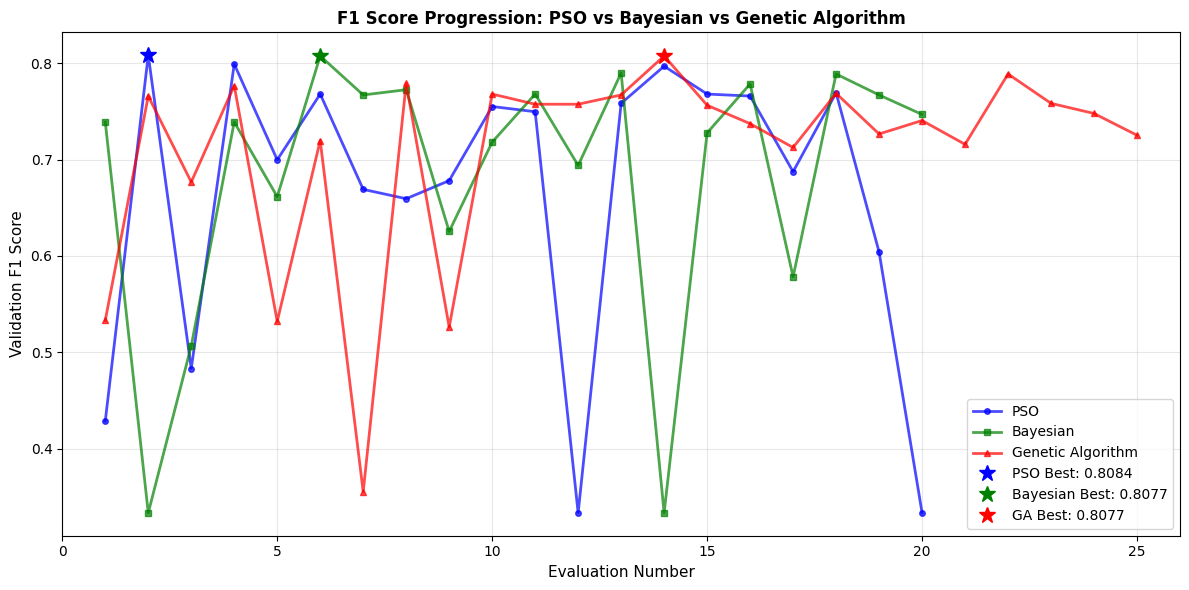

In [ ]:
# Cell 15e: F1 Progression Comparison (All Algorithms)

fig, ax = plt.subplots(figsize=(12, 6))

# Plot PSO progression
pso_evals = [r['eval_num'] for r in pso_all_results]
pso_f1 = [r['val_f1'] for r in pso_all_results]
ax.plot(pso_evals, pso_f1, 'b-o', linewidth=2, markersize=4, alpha=0.7, label='PSO')

# Plot Bayesian progression
bayesian_evals = [r['eval_num'] for r in bayesian_all_results]
bayesian_f1 = [r['val_f1'] for r in bayesian_all_results]
ax.plot(bayesian_evals, bayesian_f1, 'g-s', linewidth=2, markersize=4, alpha=0.7, label='Bayesian')

# Plot GA progression
ga_evals = [r['eval_num'] for r in ga_all_results]
ga_f1 = [r['val_f1'] for r in ga_all_results]
ax.plot(ga_evals, ga_f1, 'r-^', linewidth=2, markersize=4, alpha=0.7, label='Genetic Algorithm')

# Mark best points
ax.plot(pso_best['eval_num'], pso_best['val_f1'], 'b*', markersize=12, label=f"PSO Best: {pso_best['val_f1']:.4f}")
ax.plot(bayesian_best['eval_num'], bayesian_best['val_f1'], 'g*', markersize=12, label=f"Bayesian Best: {bayesian_best['val_f1']:.4f}")
ax.plot(ga_best['eval_num'], ga_best['val_f1'], 'r*', markersize=12, label=f"GA Best: {ga_best['val_f1']:.4f}")

ax.set_xlabel('Evaluation Number', fontsize=11)
ax.set_ylabel('Validation F1 Score', fontsize=11)
ax.set_title('F1 Score Progression: PSO vs Bayesian vs Genetic Algorithm', fontsize=12, fontweight='bold')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, max(max(pso_evals), max(bayesian_evals), max(ga_evals)) + 1])

plt.tight_layout()
plt.show()

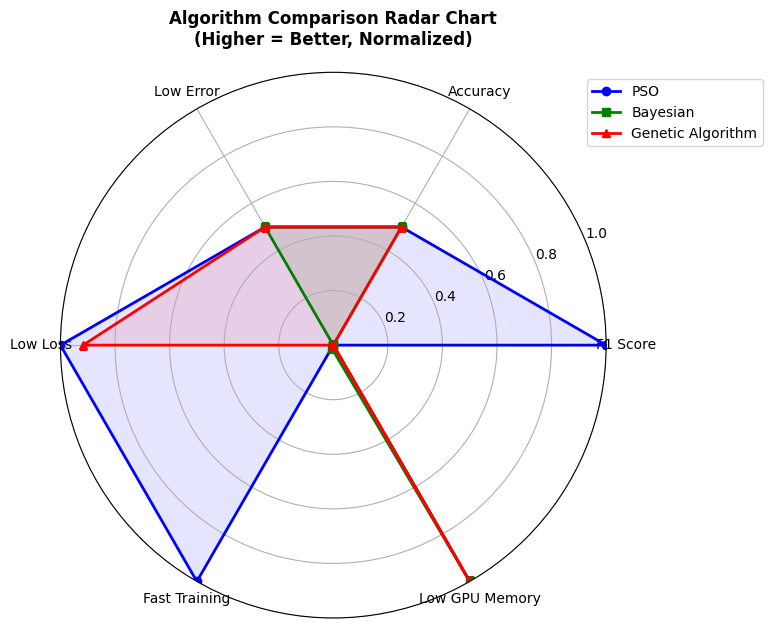

In [ ]:
# Cell 15f: Radar Chart for Comprehensive Comparison

import numpy as np

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

# Metrics to compare (normalized)
metrics = ['F1 Score', 'Accuracy', 'Low Error', 'Low Loss', 'Fast Training', 'Low GPU Memory']

# Normalize values (0 to 1, where 1 is best)
def normalize(values, higher_better=True):
    if higher_better:
        return (values - min(values)) / (max(values) - min(values))
    else:
        return 1 - (values - min(values)) / (max(values) - min(values))

# Extract values
pso_values = [pso_best['val_f1'], pso_best['val_accuracy'], 1-pso_best['val_error'],
              1-pso_best['val_loss'], 1/pso_best['training_time'], 1/pso_best['gpu_memory_mb']]
bayesian_values = [bayesian_best['val_f1'], bayesian_best['val_accuracy'], 1-bayesian_best['val_error'],
                   1-bayesian_best['val_loss'], 1/bayesian_best['training_time'], 1/bayesian_best['gpu_memory_mb']]
ga_values = [ga_best['val_f1'], ga_best['val_accuracy'], 1-ga_best['val_error'],
             1-ga_best['val_loss'], 1/ga_best['training_time'], 1/ga_best['gpu_memory_mb']]

# Normalize across algorithms for each metric
num_metrics = len(metrics)
angles = np.linspace(0, 2 * np.pi, num_metrics, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

# Normalize each metric across the three algorithms
all_values = np.array([pso_values, bayesian_values, ga_values])
normalized_values = np.zeros_like(all_values)

for i in range(num_metrics):
    col_values = all_values[:, i]
    if max(col_values) != min(col_values):
        normalized_values[:, i] = (col_values - min(col_values)) / (max(col_values) - min(col_values))
    else:
        normalized_values[:, i] = 0.5

# Plot each algorithm
pso_norm = normalized_values[0].tolist()
pso_norm += pso_norm[:1]
ax.plot(angles, pso_norm, 'b-o', linewidth=2, label='PSO')
ax.fill(angles, pso_norm, alpha=0.1, color='blue')

bayesian_norm = normalized_values[1].tolist()
bayesian_norm += bayesian_norm[:1]
ax.plot(angles, bayesian_norm, 'g-s', linewidth=2, label='Bayesian')
ax.fill(angles, bayesian_norm, alpha=0.1, color='green')

ga_norm = normalized_values[2].tolist()
ga_norm += ga_norm[:1]
ax.plot(angles, ga_norm, 'r-^', linewidth=2, label='Genetic Algorithm')
ax.fill(angles, ga_norm, alpha=0.1, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics, fontsize=10)
ax.set_ylim([0, 1])
ax.set_title('Algorithm Comparison Radar Chart\n(Higher = Better, Normalized)', fontsize=12, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.0))

plt.tight_layout()
plt.show()

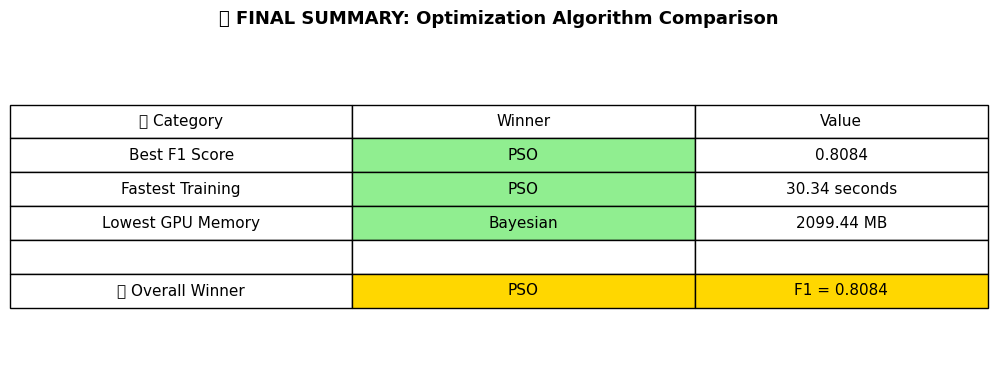


COMPARISON COMPLETE

📈 Key Insights:
   • Best F1 Score: PSO with 0.8084
   • Fastest Training: PSO (30.34s)
   • Most Memory Efficient: Bayesian (2099.44 MB)

🏆 Overall Champion: PSO
   Best F1: 0.8084


In [ ]:
# Cell 15g: Final Summary and Recommendations

fig, ax = plt.subplots(figsize=(10, 4))
ax.axis('tight')
ax.axis('off')

# Find best in each category
best_f1_algo = max([('PSO', pso_best['val_f1']), ('Bayesian', bayesian_best['val_f1']), ('GA', ga_best['val_f1'])], key=lambda x: x[1])
best_time_algo = min([('PSO', pso_best['training_time']), ('Bayesian', bayesian_best['training_time']), ('GA', ga_best['training_time'])], key=lambda x: x[1])
best_memory_algo = min([('PSO', pso_best['gpu_memory_mb']), ('Bayesian', bayesian_best['gpu_memory_mb']), ('GA', ga_best['gpu_memory_mb'])], key=lambda x: x[1])

summary_data = [
    ['🏆 Category', 'Winner', 'Value'],
    ['Best F1 Score', f"{best_f1_algo[0]}", f"{best_f1_algo[1]:.4f}"],
    ['Fastest Training', f"{best_time_algo[0]}", f"{best_time_algo[1]:.2f} seconds"],
    ['Lowest GPU Memory', f"{best_memory_algo[0]}", f"{best_memory_algo[1]:.2f} MB"],
    ['', '', ''],
    ['📊 Overall Winner', f"{overall_algorithm}", f"F1 = {overall_best['val_f1']:.4f}"]
]

summary_table = ax.table(cellText=summary_data, cellLoc='center', loc='center', colWidths=[0.35, 0.35, 0.3])
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(11)
summary_table.scale(1.2, 1.8)

# Highlight winner rows (FIXED row indices)
# Row 0 is header, so data rows start at 1
summary_table[(1, 1)].set_facecolor('#90EE90')  # Best F1 winner (row 1)
summary_table[(2, 1)].set_facecolor('#90EE90')  # Fastest training winner (row 2)
summary_table[(3, 1)].set_facecolor('#90EE90')  # Lowest memory winner (row 3)
summary_table[(5, 1)].set_facecolor('#FFD700')  # Gold for overall winner (row 5)
summary_table[(5, 2)].set_facecolor('#FFD700')  # Gold for overall winner value

plt.title('🏆 FINAL SUMMARY: Optimization Algorithm Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("COMPARISON COMPLETE")
print("=" * 60)
print(f"\n📈 Key Insights:")
print(f"   • Best F1 Score: {best_f1_algo[0]} with {best_f1_algo[1]:.4f}")
print(f"   • Fastest Training: {best_time_algo[0]} ({best_time_algo[1]:.2f}s)")
print(f"   • Most Memory Efficient: {best_memory_algo[0]} ({best_memory_algo[1]:.2f} MB)")
print(f"\n🏆 Overall Champion: {overall_algorithm}")
print(f"   Best F1: {overall_best['val_f1']:.4f}")
print("=" * 60)